<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/RA1_TP2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_2%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Análisis Exploratorio de Datos



---
#Ejercicio 1: Comprensión inicial de datos reales

---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

>Una empresa inmobiliaria desea comprender mejor el mercado de viviendas de su región. Para apoyar sus decisiones comerciales, cuenta con un registro histórico de propiedades que incluye variables como precio de venta, superficie total, cantidad de habitaciones, antigüedad del inmueble, barrrio, entre otras.
>
>El dataset se encuentra en el archivo adjunto denominado **"propiedades.csv"**.
>
>El objetivo de este ejercicio es realizar una exploración incial completa del dataset.

---
##0. Configuracion del entorno

In [12]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

datasetPropiedades = pd.read_csv("/content/propiedades.csv")


---

## 1. Carga y primera inspección

In [ ]:
print("Primeras 10 filas del dataset:\n")
datasetPropiedades.head(10)

Primeras 10 filas del dataset:



,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59
5,6,301300.0,100.6,3,29.0,Recoleta,2995.03
6,7,161000.0,49.3,2,1.0,Palermo,3265.72
7,8,309100.0,112.0,5,50.0,Palermo,2759.82
8,9,175500.0,93.0,2,27.0,Centro,1887.10
9,10,43200.0,44.0,2,41.0,Sur,981.82


Al mirar las primeras 10 muestras del dataset se observó que las **filas** representan un registro histórico único de una propiedad inmobiliaria particular puesta a la venta en la región.


Por otro lado cada **columna** representa una característica o atributo específico de esa propiedad (como el precio de venta o superficie total por ejemplo). La columna `id` es simplemente un identificador único para cada registro.

In [ ]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetPropiedades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


Haciendo uso del metodo `.info()` se evidencian 800 instancias (`entries`, filas) y 7 variables (columnas).


A simple vista se detecta que tipos de variables presentes son los siguientes:

*   `id`: Identificador único.
*   `precio`, `superficie_m2`, `precio_m2`, `antiguedad_años`: variables numericas continuas.
*   `habitaciones`: variable numerica discreta.
*   `barrio`: variable categórica.


En el contexto de un Análisis Explotariorio de Datos (EDA) inicial para un mercado inmobiliario regional, 800 observaciones es un volumen estadísticamente decente. Esta cantidad nos permite realizar agrupaciones decente. Esta cantidad nos permite realizar agrupaciones, calcular medidas de tendencia central, de dispersión de confianza, y construir una intuición analítica sólida sin que valores extremos (outliers) distorsiones fuertemente las conclusiones generales.

Tambien, podemos apreciar que no todas las variables tienen un tipo de dato adecuado del todo. Si bien las variables continuas (`precio`, `superficie_m2`, `precio_m2`) y categóricas (`barrio`) tienen tipos de datos computacionales correctos (float64 y object), se detectó una discrepancia en la variable `antiguedad_años`.

Desde la teoría estadística, la antigúedad en años es una variable **numérica discreta**, por lo que su tipo computacional ideal debería ser entero (`int64`). Sin embargo, el método `.info()` revela que está cargada como `float64`.

Nuestra hipótesis es que esta anomalía se debe a la presencia de valores nulos en dicha columna (solo posee 752 valores no nulos sobre 800). En la arquitectura de Pandas, la inclusión de valores `NaN` fuerza a que toda columna convierta a punto flotante. para corregir este tipo de dato, primero se deberá tomar una decisión sobre cómo tratar o imputar estos valores faltantes en la etapa de Calidad de Datos.


---
##2. Calidad de los datos

###2.1 Valores Faltantes

In [ ]:
datasetPropiedades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


In [ ]:
faltantes = datasetPropiedades.isnull().sum()
pct_faltantes = (faltantes / len(datasetPropiedades) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "Cantidad": faltantes,
    "Porcentaje (%)": pct_faltantes
}).query("Cantidad > 0")

print("Variables con valores faltantes:")
print(resumen_faltantes)


Variables con valores faltantes:
                 Cantidad  Porcentaje (%)
precio                 32             4.0
antiguedad_años        48             6.0
precio_m2              32             4.0



Existen valores nulos en dos variables:
- `precio`: **32 valores faltantes (4%)**.
- `antiguedad_años`: **48 valores faltantes (6%)**.
- `precio_m2` hereda los faltantes de `precio` por ser una variable derivada.

###2.2 Detección de valores inconsistentes o erróneos

Ahora vamos a verificar si existen valores negativos en las columnas numéricas que no deberían tenerlos, como `precio`, `superficie_m2`, `precio_m2`, `habitaciones` y `antiguedad_años`.

In [ ]:
columnas_numericas = ['precio', 'superficie_m2', 'precio_m2', 'antiguedad_años', 'habitaciones']

for col in columnas_numericas:
    if col in datasetPropiedades.columns:
        valores_negativos = datasetPropiedades[datasetPropiedades[col] < 0]
        if not valores_negativos.empty:
            print(f"Se encontraron valores negativos en la columna '{col}':")
            display(valores_negativos)
        else:
            print(f"No se encontraron valores negativos en la columna '{col}'.")
    else:
        print(f"La columna '{col}' no existe en el dataset.")

No se encontraron valores negativos en la columna 'precio'.
No se encontraron valores negativos en la columna 'superficie_m2'.
No se encontraron valores negativos en la columna 'precio_m2'.
No se encontraron valores negativos en la columna 'antiguedad_años'.
No se encontraron valores negativos en la columna 'habitaciones'.


###2.3 Decisiones a tomar frente a valores faltantes

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

Para variables numéricas, si son pocas las faltantes se suele **imputar** (rellenar) con la mediana.
Si es categorica y faltan muchos datos se puede imputar con la moda pero se sesgaria mucho los datos, o se puede eliminar las filas con esta información.

Si los valores faltantes son muchos para un tipo de dato no conviene eliminar, si el dato es numerico se puede imputar usando el promedio con los datos que no faltan
Si hay datos atípicos (outliers), en ese caso es mejor utilizar la mediana.
Se puede ignorar algunos datos dependiendo de la lógica, si el dato es piscina y falta el dato que indique si posee o no, indica que no posee, y que no se decidió anotar.


In [ ]:
# @title Se decide eliminar los datos con precio faltante y imputar los datos con antiguedad_años nulos con la mediana.
# Aplicar las decisiones de limpieza
datasetPropiedadesClean = datasetPropiedades.dropna(subset=["precio"]).copy()

# Imputar antiguedad con mediana por barrio
datasetPropiedadesClean["antiguedad_años"] = datasetPropiedadesClean.groupby("barrio")["antiguedad_años"].transform(
    lambda x: x.fillna(x.median())
)

# Verificar resultado
print(f"Filas después de eliminar los datos de precio nulos: {len(datasetPropiedadesClean)} (se eliminaron {len(datasetPropiedades) - len(datasetPropiedadesClean)})")
print(f"Faltantes restantes:\n{datasetPropiedadesClean.isnull().sum()}")

Filas después de eliminar los datos de precio nulos: 768 (se eliminaron 32)
Faltantes restantes:
id                 0
precio             0
superficie_m2      0
habitaciones       0
antiguedad_años    0
barrio             0
precio_m2          0
dtype: int64


Análisis de 'superficie_m2' antes de eliminar outliers:


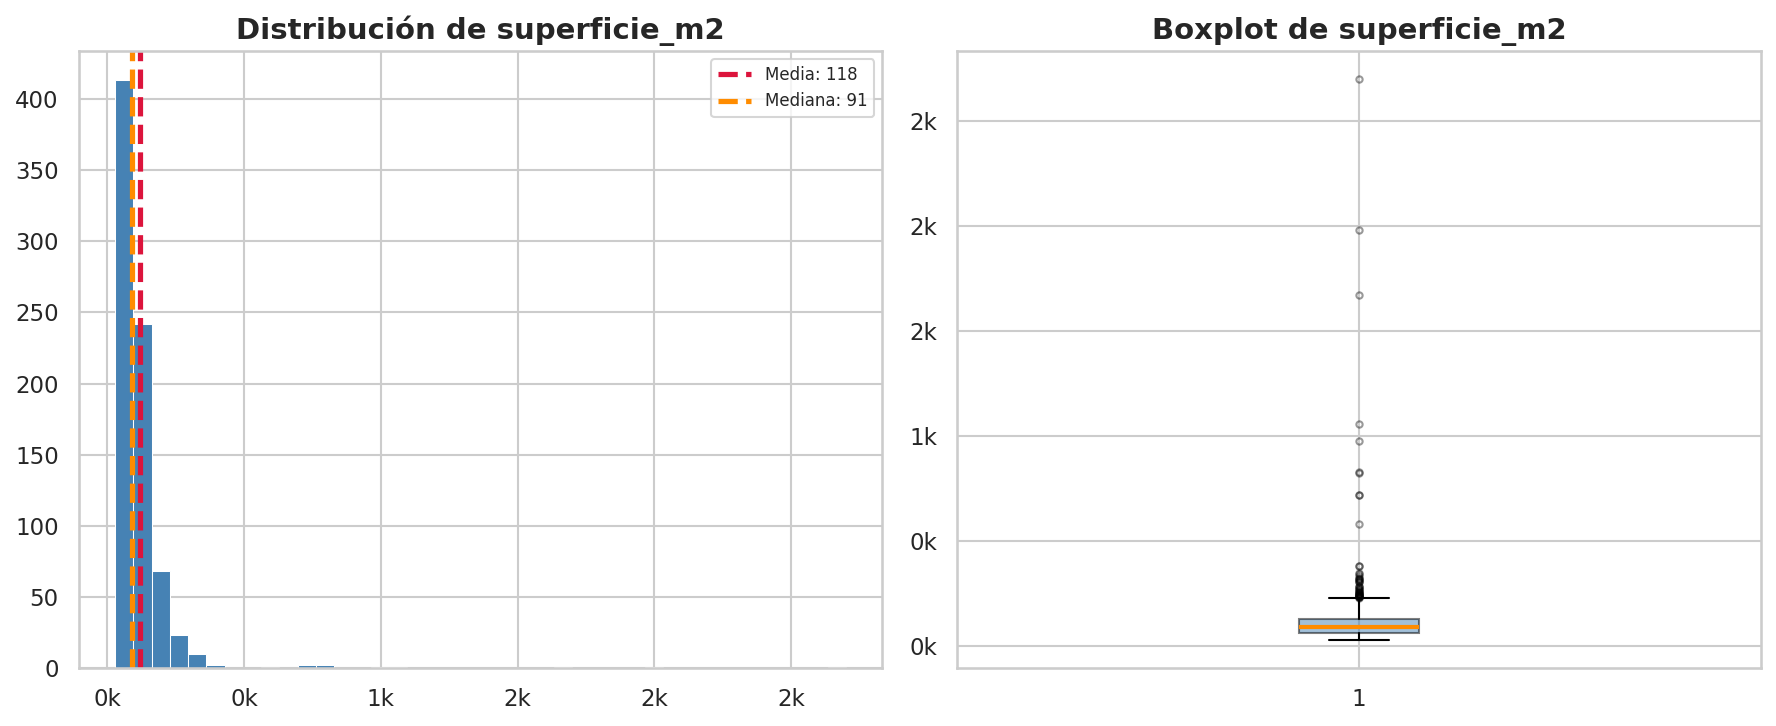

Variable: SUPERFICIE_M2
  > Límite superior IQR: 229.05
  > Límite inferior IQR: -37.95
  > Outliers detectados: 45 (5.9%)
------------------------------

Valores atípicos en 'superficie_m2' y sus precios correspondientes:


,superficie_m2,precio
0,232.9,648900.0
12,241.9,303700.0
68,247.2,505700.0
70,256.6,387400.0
72,236.1,541500.0
76,380.0,543000.0
122,719.0,169600.0
135,279.5,648300.0
155,253.4,682200.0
187,309.0,569600.0



Filas antes de eliminar outliers de 'superficie_m2': 768
Filas después de eliminar outliers de 'superficie_m2': 723
Se eliminaron 45 filas.

Análisis de 'superficie_m2' después de eliminar outliers:


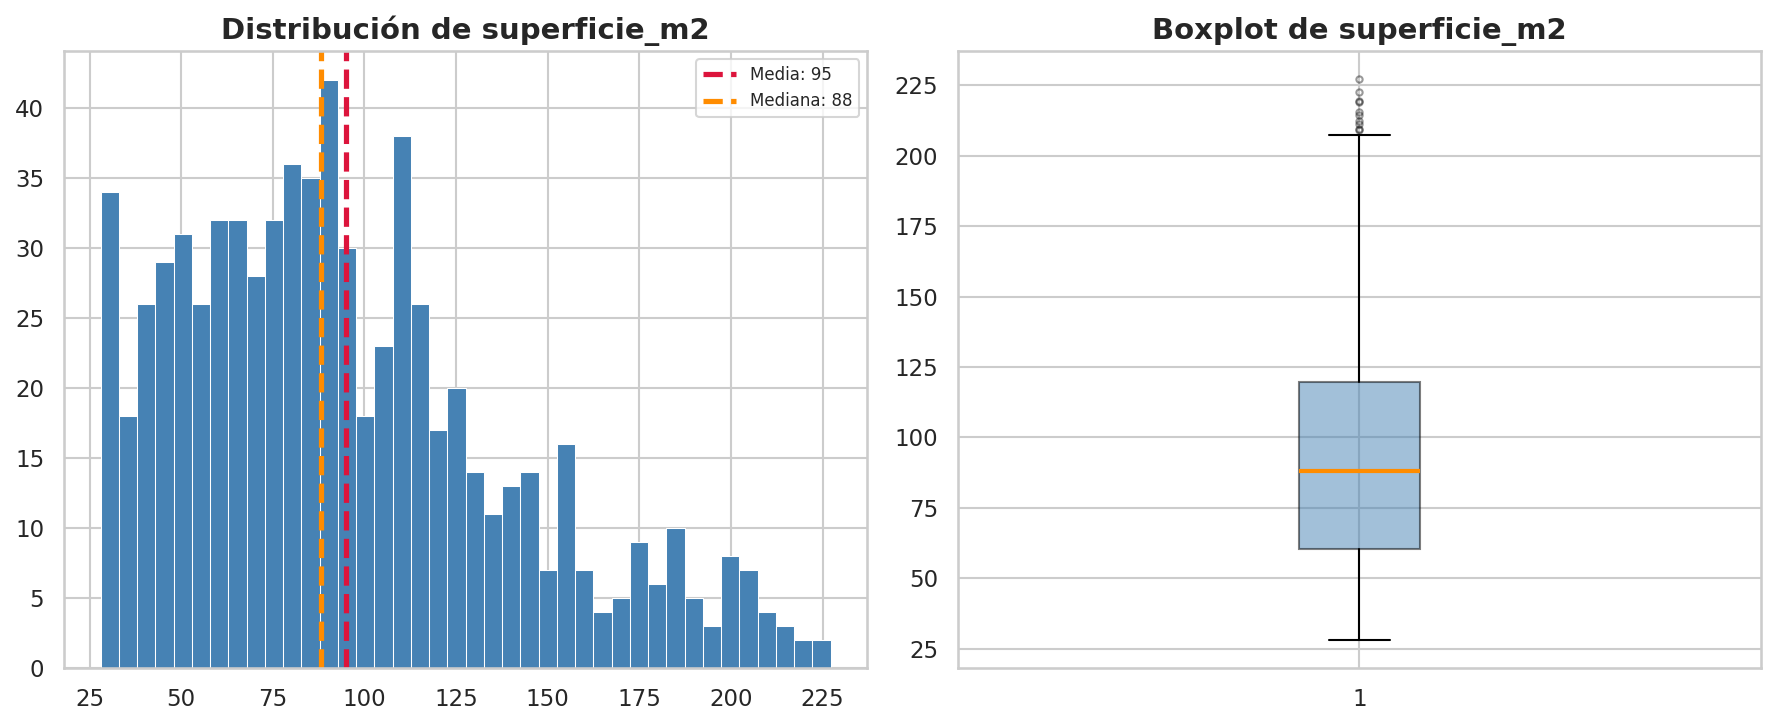

Variable: SUPERFICIE_M2
  > Límite superior IQR: 208.40
  > Límite inferior IQR: -28.40
  > Outliers detectados: 10 (1.4%)
------------------------------


(np.float64(-28.4),
 np.float64(208.39999999999998),
       id    precio  superficie_m2  habitaciones  antiguedad_años     barrio  \
 61    62  240900.0          212.4             6              5.0        Sur   
 133  134  316400.0          215.6             5             24.0      Norte   
 163  164  468300.0          222.7             5              1.0     Centro   
 190  191  183200.0          219.0             5             54.0  Mataderos   
 326  327  567900.0          214.5             5              3.0   Belgrano   
 420  421  321600.0          209.0             6             38.0       Este   
 469  470  233500.0          211.3             6              5.0        Sur   
 472  473  559600.0          227.2             7             25.0     Centro   
 500  501  594600.0          209.6             6             12.0    Palermo   
 507  508  552800.0          219.4             6             11.0   Belgrano   
 
      precio_m2  
 61     1134.18  
 133    1467.53  
 163    210

In [ ]:
# @title Esta celda realiza el analisis de superficie y precio, y luego elimina los valores atipicos (outliers)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

def plot_univariate_analysis_and_outliers(data, var, color="steelblue"):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    data_series = data[var].dropna()

    # --- 1. HISTOGRAMA ---
    axes[0].hist(data_series, bins=40, color=color, edgecolor="white", linewidth=0.5)
    mean_val = data_series.mean()
    median_val = data_series.median()
    axes[0].axvline(mean_val, color="crimson", linestyle="--", label=f"Media: {mean_val:,.0f}")
    axes[0].axvline(median_val, color="darkorange", linestyle="--", label=f"Mediana: {median_val:,.0f}")
    axes[0].set_title(f"Distribución de {var}")
    axes[0].legend(fontsize=8)

    # Use FuncFormatter for dynamic scaling of x-axis ticks if values are large
    if data_series.max() > 1000:
        axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    # --- 2. BOXPLOT ---
    axes[1].boxplot(data_series, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.5),
                       medianprops=dict(color="darkorange", linewidth=2),
                       flierprops=dict(marker="o", markersize=3, alpha=0.4, color="crimson"))
    axes[1].set_title(f"Boxplot de {var}") # Fixed SyntaxError here

    # Use FuncFormatter for dynamic scaling of y-axis ticks if values are large
    if data_series.max() > 1000:
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

    plt.tight_layout()
    plt.show()

    # Estadísticas para outliers
    q1 = data_series.quantile(0.25)
    q3 = data_series.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    lim_inf = q1 - 1.5 * iqr

    outliers_data = data[(data[var] > lim_sup) | (data[var] < lim_inf)]

    print(f"Variable: {var.upper()}")
    print(f"  > Límite superior IQR: {lim_sup:,.2f}")
    print(f"  > Límite inferior IQR: {lim_inf:,.2f}")
    print(f"  > Outliers detectados: {len(outliers_data)} ({len(outliers_data)/len(data_series)*100:.1f}%)")
    print("-" * 30)
    return lim_inf, lim_sup, outliers_data

# Visualize and get outlier limits and data for 'superficie_m2'
print("Análisis de 'superficie_m2' antes de eliminar outliers:")
lim_inf_superficie, lim_sup_superficie, superficie_outliers = plot_univariate_analysis_and_outliers(datasetPropiedadesClean, 'superficie_m2')

# Display 'superficie_m2' and 'precio' for the identified outliers
if not superficie_outliers.empty:
    print("\nValores atípicos en 'superficie_m2' y sus precios correspondientes:")
    display(superficie_outliers[['superficie_m2', 'precio']])
else:
    print("\nNo se encontraron outliers en 'superficie_m2'.")

# Remove outliers from 'superficie_m2' in datasetPropiedadesClean
initial_rows = len(datasetPropiedadesClean)
datasetPropiedadesClean = datasetPropiedadesClean[
    (datasetPropiedadesClean['superficie_m2'] >= lim_inf_superficie) &
    (datasetPropiedadesClean['superficie_m2'] <= lim_sup_superficie)
].copy()

print(f"\nFilas antes de eliminar outliers de 'superficie_m2': {initial_rows}")
print(f"Filas después de eliminar outliers de 'superficie_m2': {len(datasetPropiedadesClean)}")
print(f"Se eliminaron {initial_rows - len(datasetPropiedadesClean)} filas.")

# Re-visualize to confirm removal
print("\nAnálisis de 'superficie_m2' después de eliminar outliers:")
plot_univariate_analysis_and_outliers(datasetPropiedadesClean, 'superficie_m2')


Acontinuación se muestra la diferencia entre la dataset limpia y se la compara con la dataset original

In [ ]:
datasetPropiedades.describe()

,id,precio,superficie_m2,habitaciones,antiguedad_años,precio_m2
count,800.0000,768.000000,800.00000,800.000000,752.000000,768.000000
mean,400.5000,200636.743398,117.63600,3.428750,21.960106,1961.878724
std,231.0844,142582.538365,154.54675,1.625801,18.556668,988.500261
min,1.0000,19900.000000,28.00000,1.000000,0.000000,116.180000
25%,200.7500,102900.000000,62.67500,2.000000,4.000000,1322.425000
50%,400.5000,160000.000000,90.95000,3.000000,18.000000,1841.940000
75%,600.2500,264075.000000,129.27500,5.000000,38.000000,2436.200000
max,800.0000,994200.000000,2700.00000,7.000000,59.000000,10111.360000


In [ ]:
datasetPropiedadesClean.describe()

,id,precio,superficie_m2,habitaciones,antiguedad_años,precio_m2
count,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000
mean,396.648686,185488.546238,94.856570,3.305671,21.904564,1992.205795
std,231.054210,118747.184091,44.932936,1.555727,18.053204,981.465760
min,2.000000,19900.000000,28.000000,1.000000,0.000000,631.750000
25%,196.500000,101500.000000,60.400000,2.000000,5.000000,1340.550000
50%,393.000000,155200.000000,88.100000,3.000000,18.000000,1872.160000
75%,597.500000,241500.000000,119.600000,4.000000,37.000000,2424.405000
max,800.000000,874865.510000,227.200000,7.000000,59.000000,10111.360000


Se observa que la superficie maxima no supera los 250 metros cuadrados, no tenemos datos atipicos que puedan afectar los demas analisis.

---
##3. Estadística Descriptiva

### 3.1 Alta variabilidad entre datos



In [ ]:
columnas_numericas = datasetPropiedadesClean.select_dtypes(include=['number']).columns

# Calcular la media y la desviación estándar para cada columna numérica
valores_media = datasetPropiedadesClean[columnas_numericas].mean()
valores_desviacion = datasetPropiedadesClean[columnas_numericas].std()

# CV = Desviación Estándar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados de manera ordenada
cv_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
}).sort_values(by='Coeficiente de Variación', ascending=False)

display(cv_df)

,Media,Desviación Estándar,Coeficiente de Variación
antiguedad_años,21.904564,18.053204,0.824175
precio,185488.546238,118747.184091,0.640186
id,396.648686,231.054210,0.582516
precio_m2,1992.205795,981.465760,0.492653
superficie_m2,94.856570,44.932936,0.473693
habitaciones,3.305671,1.555727,0.470624


La variable que presenta mayor variabilidad relativa es la antiguedad de las viviendas, con un coeficiente de variación (CV) de 0,82, mientras que el CV del resto de variables esta entre 0.47 y 0.64.

###3.2 La mediana y la media, sus diferencias y efectos en la forma de la distribución

In [ ]:
# @title Tabla de media, mediana, Dif. Absoluta, Dif. Porcentual de cada variable.
# Calcular la media y la mediana para cada columna numérica
median_values = datasetPropiedadesClean[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - median_values).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': median_values,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(diferencia_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
antiguedad_años,21.904564,18.00,3.904564,17.825346
precio,185488.546238,155200.00,30288.546238,16.329066
habitaciones,3.305671,3.00,0.305671,9.246862
superficie_m2,94.856570,88.10,6.756570,7.122933
precio_m2,1992.205795,1872.16,120.045795,6.025773
id,396.648686,393.00,3.648686,0.919879


Existe una diferencia significativa entre la media y la mediana en casi todas las variables, principalmente en la superficie, el precio y la antigüedad del mobiliario. Esto es un indicativo de que las distribuciones no son simétricas y están sesgadas. En este caso todas las medianas son menores que las medias, por lo que las distribuciones estan sesgadas hacia la derecha.

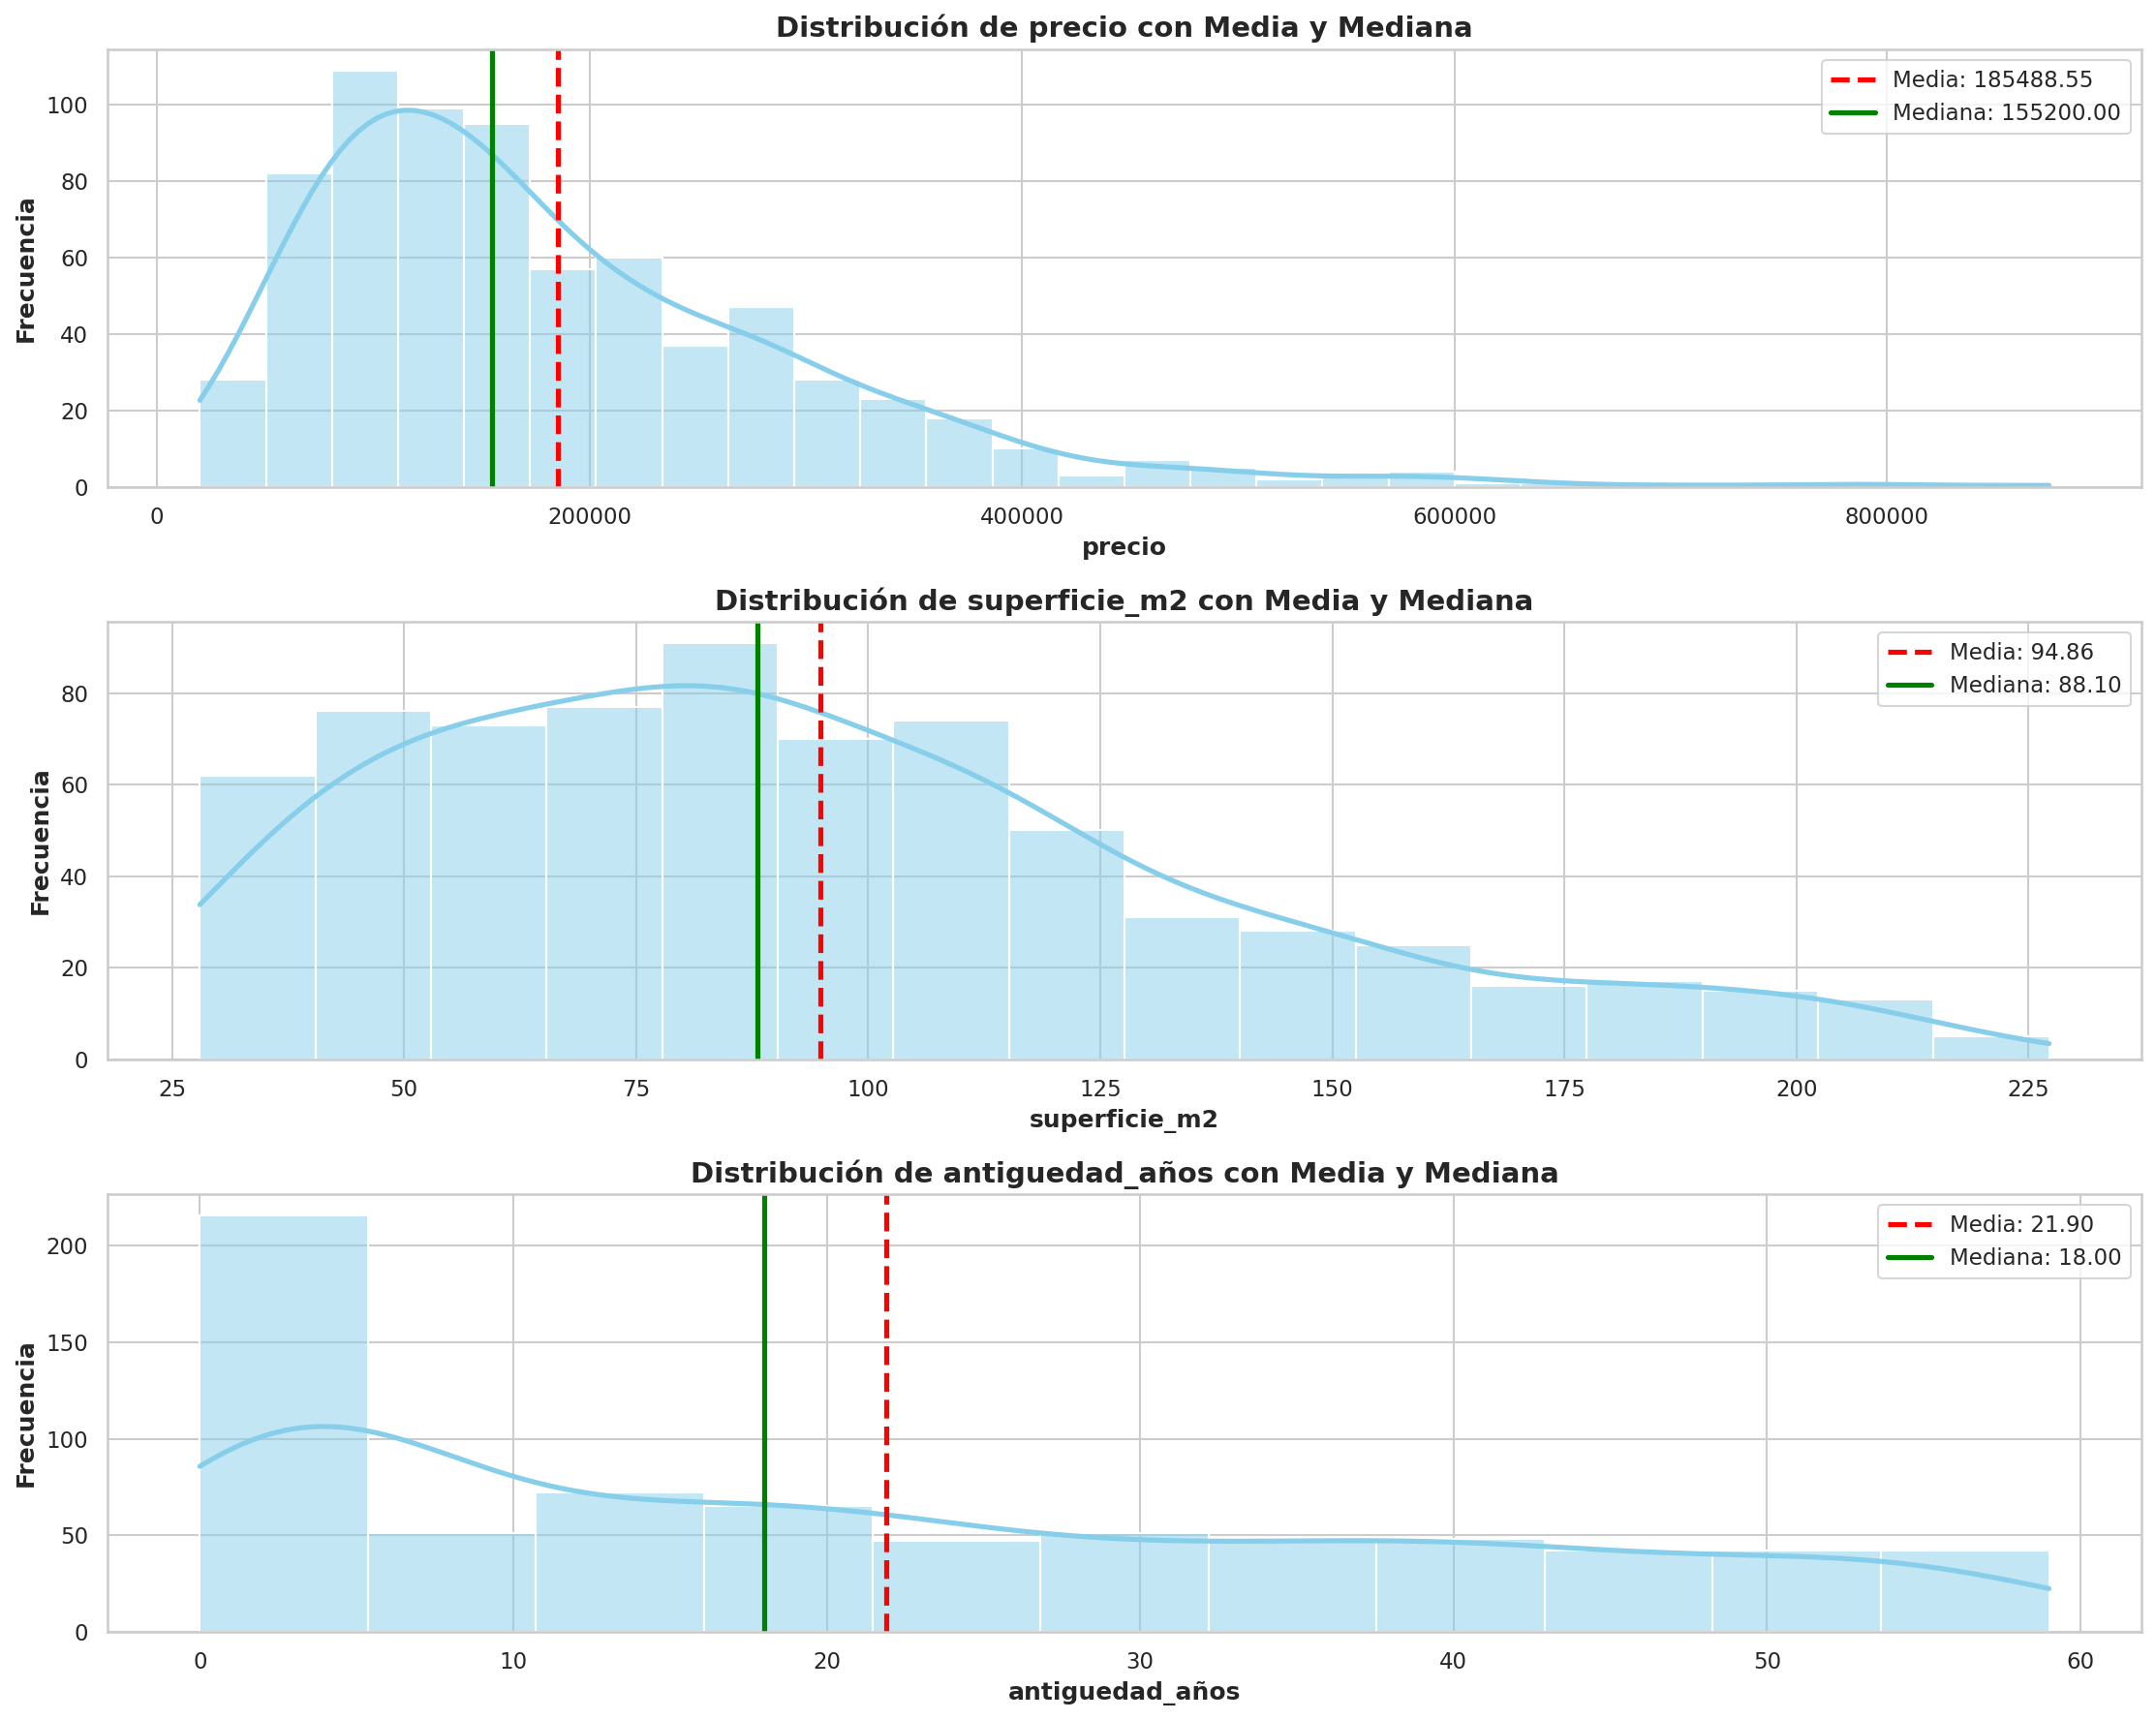

In [ ]:
variables_to_plot = ['precio', 'superficie_m2', 'antiguedad_años']

plt.figure(figsize=(15, 12))

for i, var in enumerate(variables_to_plot):
    plt.subplot(3, 1, i + 1)
    sns.histplot(datasetPropiedadesClean[var], kde=True, color='skyblue')

    # Calculate mean and median for the current variable
    mean_val = datasetPropiedadesClean[var].mean()
    median_val = datasetPropiedadesClean[var].median()

    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    plt.title(f'Distribución de {var} con Media y Mediana')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend()

plt.tight_layout()
plt.show()

Como podemos observar en los histogramas de `precio`, `superficie_m2` y `antiguedad_años`, la línea roja de la media y la línea verde de la mediana no coinciden. La media (roja) se encuentra a la derecha de la mediana (verde) en las tres variables, lo que indica una asimetría positiva o un sesgo hacia la derecha. Esto significa que la mayoría de los valores se concentran en el lado izquierdo de la distribución, pero hay algunos valores extremos altos que "empuja" la media hacia la derecha. Esto se alinea con las observaciones previas de que estas distribuciones no son simétricas y que la mediana es una medida de tendencia central más representativa que la media en estos casos.

###3.3 Similitudes entre distribuciones

Hagamos un enfasis en la grafica anterior de la distribución del precio, y comparemosla con la siguiente grafica de una distribución logaritmica normal.

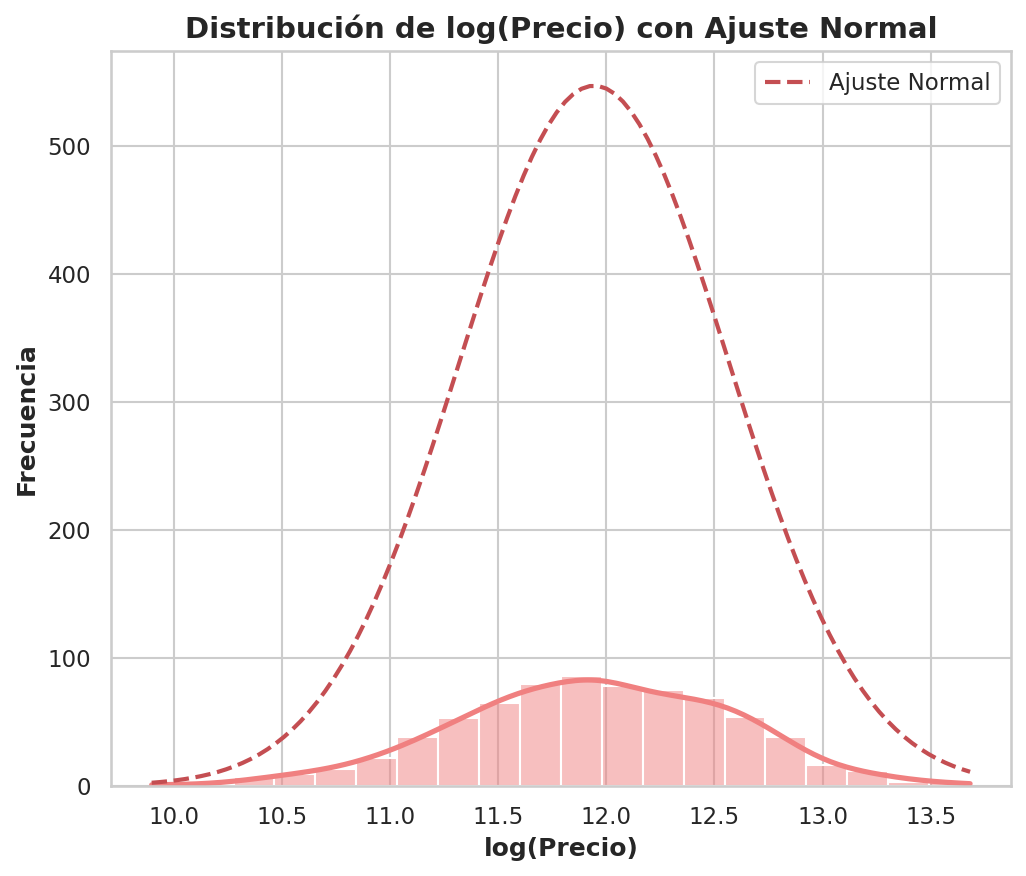

In [ ]:
# Eliminar valores nulos de la columna 'precio' para el análisis
datos_precio = datasetPropiedadesClean['precio'].dropna()

# Crear la figura y un subplot para la distribución de log(precio)
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Subplot: Distribución de log(precio) y ajuste a una distribución normal
log_precio = np.log(datos_precio)
sns.histplot(log_precio, kde=True, ax=ax, color='lightcoral')

# Ajustar una distribución normal a log_precio
mu, std = norm.fit(log_precio)
x_range = np.linspace(log_precio.min(), log_precio.max(), 100)
p_normal = norm.pdf(x_range, mu, std)

# Escalar la PDF para que se ajuste a la altura del histograma
max_hist_height = ax.patches[0].get_height() if ax.patches else 1
max_pdf_height = p_normal.max()
factor_de_escala = (max_hist_height / max_pdf_height) * (len(log_precio) * (log_precio.max() - log_precio.min()) / len(ax.get_xticks()))

ax.plot(x_range, p_normal * factor_de_escala, 'r--', linewidth=2, label='Ajuste Normal')

ax.set_title('Distribución de log(Precio) con Ajuste Normal')
ax.set_xlabel('log(Precio)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

Es una distribución con una visible asimetría positiva, y se asemeja a la distribución Log-Normal. Esto representa que hay más propiedades de precios bajos, pero existen algunas de lujo o de precios muy altos (valores atípicos) que elevan el promedio, por lo que en este caso la mediana es una medida de tendencia central mas representativa que la media aritmética.

---
##4 Visualización y detección de outliers

Las cuatro variables numéricas para su análisis serán `precio`, `superficie_m2`, `habitaciones`y `antiguedad`.

###4.1 Precio

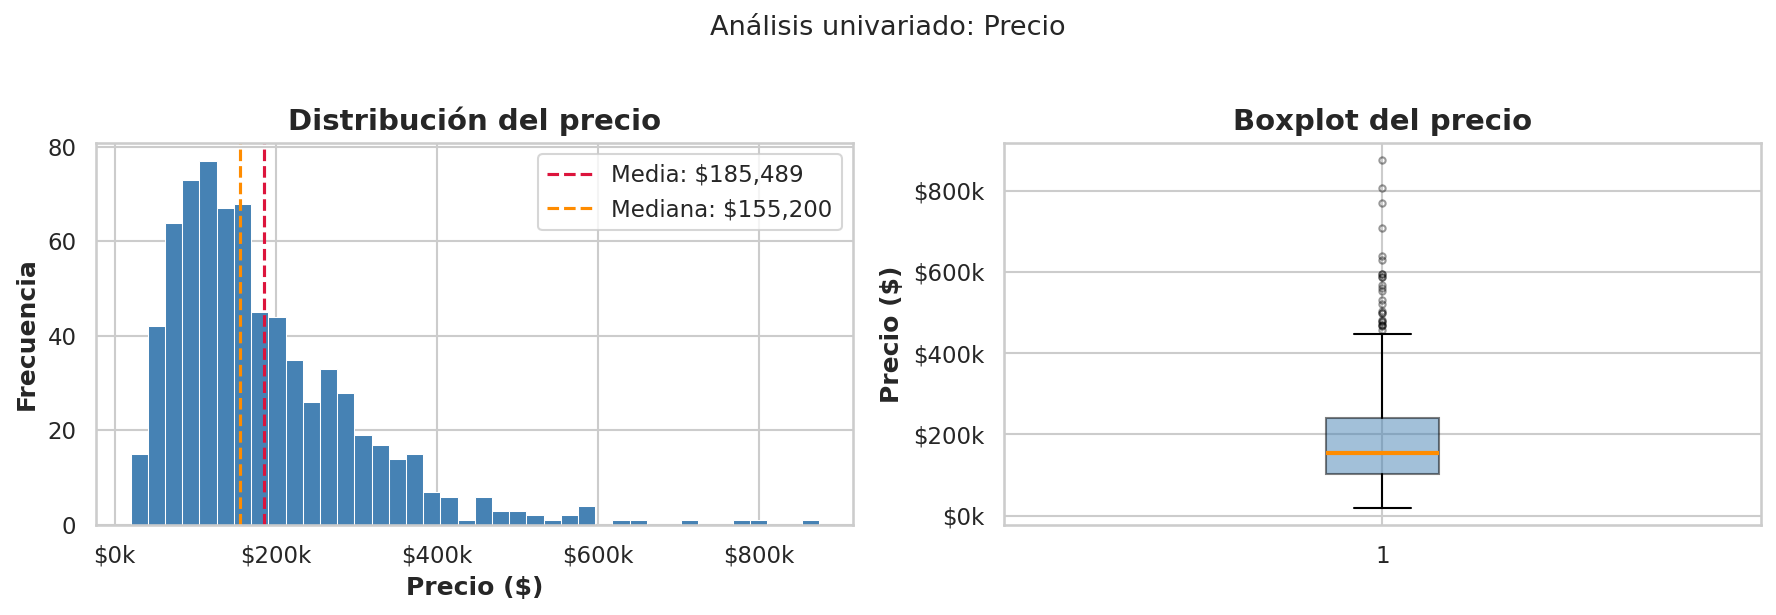

Límite superior IQR: $451,500
Outliers de precio detectados (IQR): 25 (3.5%)

Las 5 propiedades más caras:
 id    precio  superficie_m2  habitaciones   barrio
 28 874865.51          161.2             6   Centro
161 805621.11           90.3             3   Centro
388 770600.00          202.3             5 Recoleta
256 707693.37           73.7             3  Palermo
224 640300.00          185.5             6 Recoleta


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(datasetPropiedadesClean["precio"].dropna(), bins=40, color="steelblue",
             edgecolor="white", linewidth=0.5)
axes[0].axvline(datasetPropiedadesClean["precio"].mean(), color="crimson",
                linestyle="--", linewidth=1.5, label=f"Media: ${datasetPropiedadesClean['precio'].mean():,.0f}")
axes[0].axvline(datasetPropiedadesClean["precio"].median(), color="darkorange",
                linestyle="--", linewidth=1.5, label=f"Mediana: ${datasetPropiedadesClean['precio'].median():,.0f}")
axes[0].set_title("Distribución del precio")
axes[0].set_xlabel("Precio ($)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
axes[0].legend()

# Boxplot
axes[1].boxplot(datasetPropiedadesClean["precio"].dropna(), vert=True,
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5),
                medianprops=dict(color="darkorange", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4, color="crimson"))
axes[1].set_title("Boxplot del precio")
axes[1].set_ylabel("Precio ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))

plt.suptitle("Análisis univariado: Precio", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Cuantificar outliers por IQR
Q1 = datasetPropiedadesClean["precio"].quantile(0.25)
Q3 = datasetPropiedadesClean["precio"].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
n_outliers = (datasetPropiedadesClean["precio"] > lim_sup).sum()
print(f"Límite superior IQR: ${lim_sup:,.0f}")
print(f"Outliers de precio detectados (IQR): {n_outliers} ({n_outliers/len(datasetPropiedadesClean)*100:.1f}%)")
print(f"\nLas 5 propiedades más caras:")
print(datasetPropiedadesClean.nlargest(5, "precio")[["id", "precio", "superficie_m2",
                                      "habitaciones", "barrio"]].to_string(index=False))


El análisis de la variable precio revela una distribución sesgada hacia la derecha (asimétrica positiva). Esto se evidencia en el histograma, donde la mayoría de las propiedades se concentran en rangos de precios más bajos, mientras que una "cola" se extiende hacia valores más altos.

La media es significativamente mayor que la mediana, lo que refuerza la idea de este sesgo. La media está siendo "arrastrada" hacia arriba por la presencia de propiedades con precios excepcionalmente altos.

El boxplot confirma la existencia de outliers en el extremo superior de la distribución, es decir, propiedades con precios muy superiores al resto. Específicamente, se detectaron 25 outliers (3.5%) por encima del límite superior del IQR de $451,500. Esto sugiere que hay un segmento de propiedades de lujo o de alto valor que se diferencian del mercado general.

Debido a esta asimetría y la presencia de outliers, la mediana se considera una medida de tendencia central más robusta y representativa del precio típico de las propiedades que la media en este dataset.

###4.2 Superficie

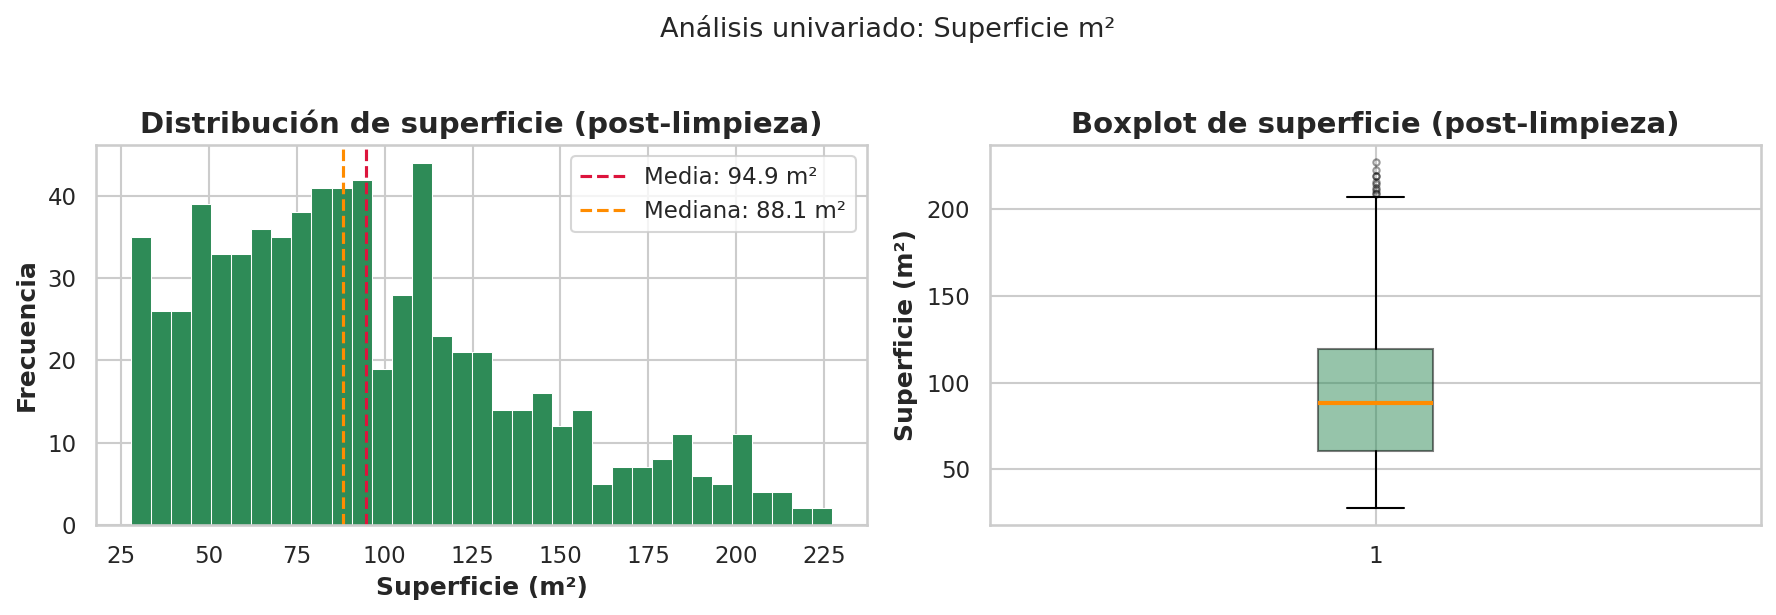

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(datasetPropiedadesClean["superficie_m2"], bins=35, color="seagreen",
             edgecolor="white", linewidth=0.5)
axes[0].axvline(datasetPropiedadesClean["superficie_m2"].mean(), color="crimson",
                linestyle="--", linewidth=1.5,
                label=f"Media: {datasetPropiedadesClean['superficie_m2'].mean():.1f} m²")
axes[0].axvline(datasetPropiedadesClean["superficie_m2"].median(), color="darkorange",
                linestyle="--", linewidth=1.5,
                label=f"Mediana: {datasetPropiedadesClean['superficie_m2'].median():.1f} m²")
axes[0].set_title("Distribución de superficie (post-limpieza)")
axes[0].set_xlabel("Superficie (m²)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].boxplot(datasetPropiedadesClean["superficie_m2"], vert=True,
                patch_artist=True,
                boxprops=dict(facecolor="seagreen", alpha=0.5),
                medianprops=dict(color="darkorange", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4, color="crimson"))
axes[1].set_title("Boxplot de superficie (post-limpieza)")
axes[1].set_ylabel("Superficie (m²)")

plt.suptitle("Análisis univariado: Superficie m²", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


El análisis de la variable `superficie_m2` después de la eliminación de outliers (que se realizó en una etapa anterior del preprocesamiento) muestra una distribución que, aunque más simétrica que la del precio, aún presenta un leve sesgo positivo. El histograma indica que la mayoría de las propiedades tienen una superficie en los rangos inferiores, con una menor cantidad de propiedades con superficies más grandes. La media y la mediana están más cerca entre sí que en el caso del precio, lo que sugiere una menor asimetría, pero la media sigue siendo ligeramente superior a la mediana, indicando la presencia de propiedades con superficies considerablemente mayores que el promedio. El boxplot visualiza una distribución más compacta y con menos valores atípicos que antes de la limpieza, lo que demuestra la efectividad de la eliminación de outliers en esta variable.

###4.3 Habitaciones y Antigüedad

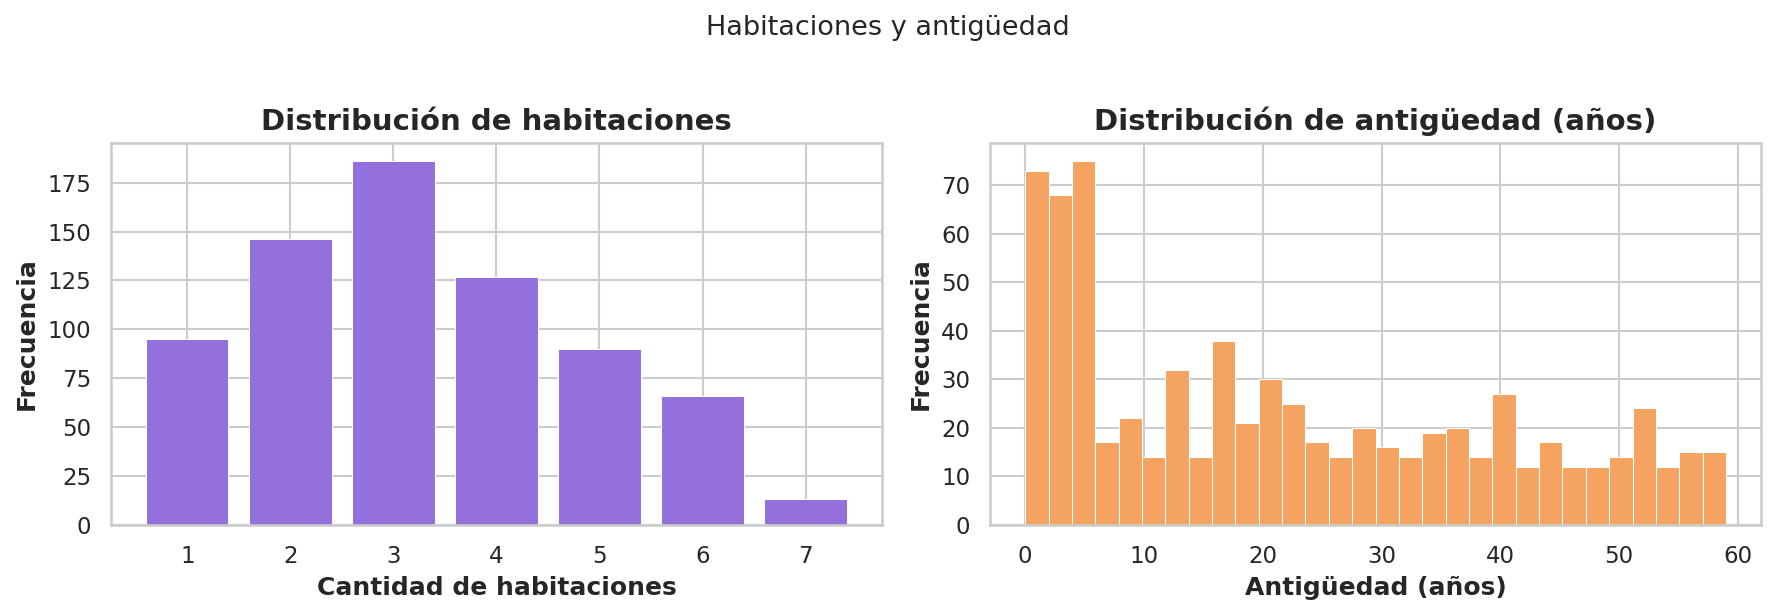

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Habitaciones: variable discreta → barras
hab_counts = datasetPropiedadesClean["habitaciones"].value_counts().sort_index()
axes[0].bar(hab_counts.index, hab_counts.values, color="mediumpurple",
            edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribución de habitaciones")
axes[0].set_xlabel("Cantidad de habitaciones")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xticks(hab_counts.index)

# Antigüedad: continua → histograma
axes[1].hist(datasetPropiedadesClean["antiguedad_años"].dropna(), bins=30,
             color="sandybrown", edgecolor="white", linewidth=0.5)
axes[1].set_title("Distribución de antigüedad (años)")
axes[1].set_xlabel("Antigüedad (años)")
axes[1].set_ylabel("Frecuencia")

plt.suptitle("Habitaciones y antigüedad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


El análisis de la variable `habitaciones` muestra una distribución donde la mayoría de las propiedades tienen entre 2 y 4 habitaciones, siendo 3 habitaciones la moda. Hay una disminución en la frecuencia a medida que aumenta el número de habitaciones, lo que es esperable en el mercado inmobiliario.

Para la variable `antiguedad_años`, se observa una distribución con un sesgo positivo, similar a las variables `precio` y `superficie_m2` antes de la limpieza de outliers. La mayoría de las propiedades son relativamente nuevas (menos de 20 años), pero existe una "cola" que se extiende hacia propiedades más antiguas (hasta 59 años). Esto indica que hay un número considerable de propiedades con mucha antigüedad en el dataset.

### 4.4 Conclusiones


Para el precio, se encontró 25 propiedades que son outliers (un 3.5% de los datos limpios). Tienen precios muy altos, por encima de  451,500.La media es mayor que la mediana, lo que muestra que hay algunas propiedades muy caras que "tiran" el promedio hacia arriba. Se estima que estos precios altos son reales para el mercado inmobiliario, son propiedades de lujo. Quitar estos datos nos haría perder información importante. Por eso, la mediana es una medida más clara del precio "típico".

En cuanto a la superficie_m2, se detectó y quitó 45 outliers (5.9%) que tenían superficies extremadamente grandes. Se decidió eliminarlos porque podrían ser errores al anotar los datos o propiedades muy diferentes a las que se buscan analizar. Al quitarlos, la información de la superficie se ve más normal y es mejor para predecir.

La variable habitaciones (de 1 a 7) no mostró valores atípicos. La mayoría de las propiedades tienen entre 2 y 4 habitaciones, lo cual es normal. Estos datos son correctos.

Finalmente, la antiguedad_años tiene muchas propiedades nuevas (menos de 20 años) pero también algunas muy viejas (hasta 59 años). Aunque estas últimas puedan parecer "fuera de lo común", son datos reales del mercado. Son casas con historia y dan una idea de la variedad de viviendas. Por eso, no deberían eliminarse.

---



---


##5. Relaciones entre variables

In [ ]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetPropiedadesClean.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59
5,6,301300.0,100.6,3,29.0,Recoleta,2995.03


Se puede observar que si se realiza el producto entre `superficie_m2` y `precio_m2` se obtine el `precio`. No aporta información nueva `precio_m2` al estar contenida en las otras 2 variables.

Si 2 variables poseen dependencia funcional directa o colinealidad, es decir el coeficientes de correlación es muy alto. El impacto que puede causar en modelos de IA predictivos, es que se confunda al estár recibir la misma información 2 veces y desestabiliza los calculos internos, esto afecta las métricas de éxito.
Entonces si se realiza la matríz de correlación las 3 variables tendrán alto coeficiente de correlación.


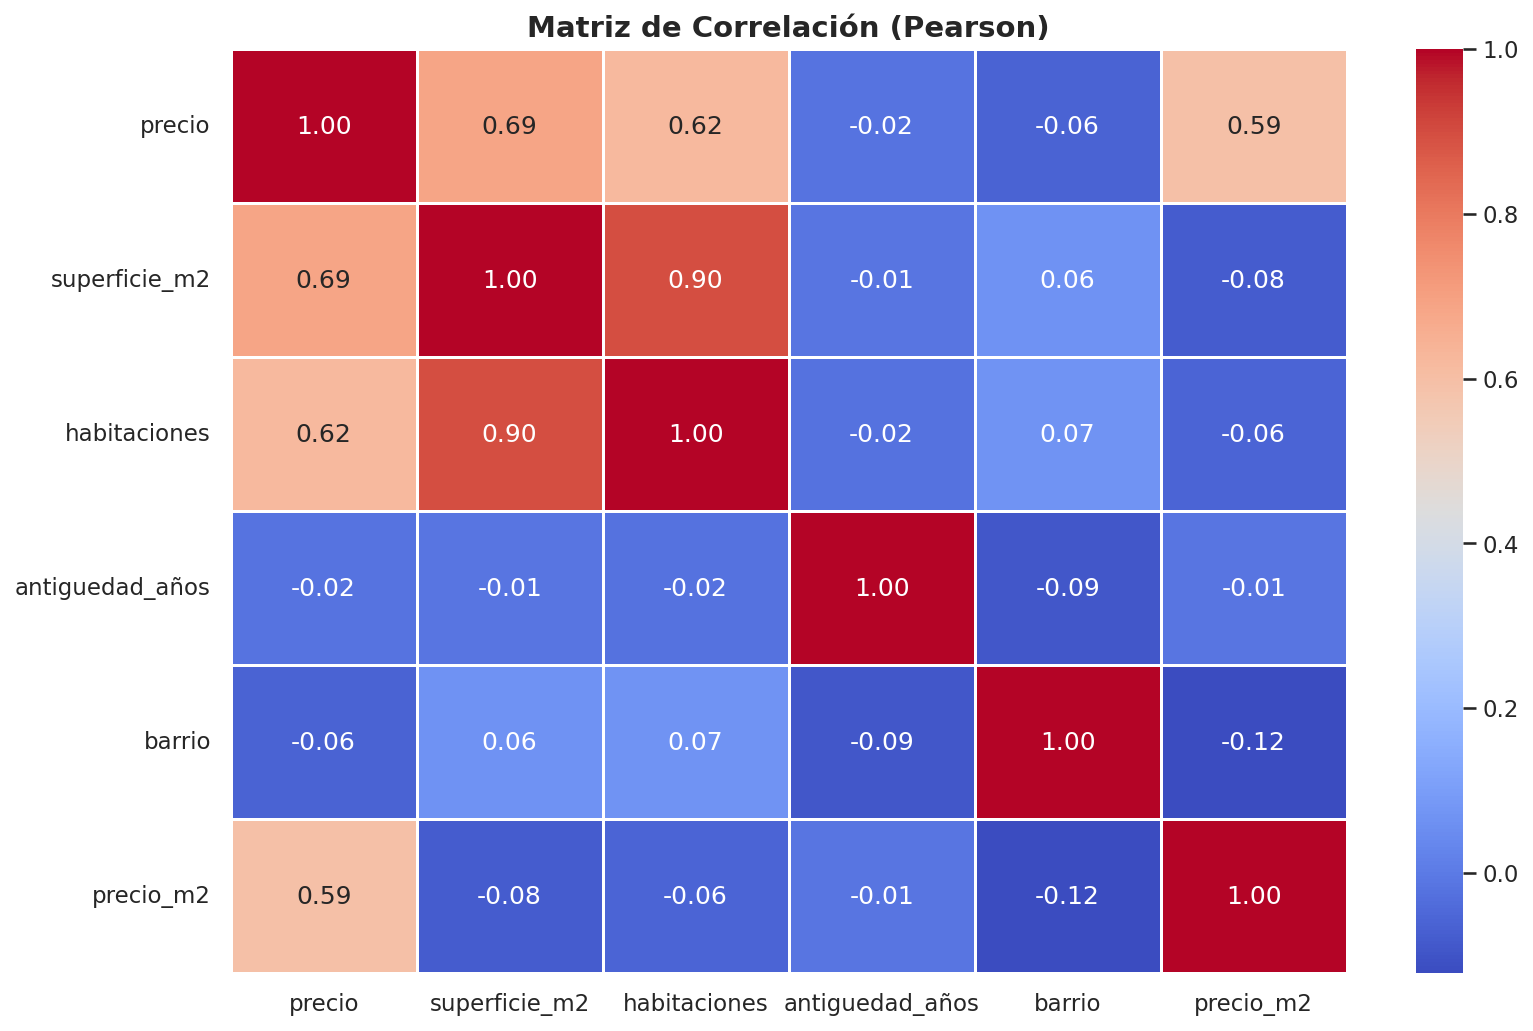

In [ ]:
dataset_encoded = datasetPropiedadesClean.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas, se pasa a numeros temporales debido a que aplicar la correlación estandar
# se trabaja con valores numéricos
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

Se puede observar que ese es el caso, si el modelo se encargase de predecir el valor de cada metro cuadrado del immueble en base a las demas variables del dataset lo mejor seria eliminar la columna del `precio_m2`.

¿Qué riesgo existiría al entrenar un algoritmo o modelo utilizando una variable de entrada que
tenga dependencia funcional directa con el valor que se quiere predecir (target)? ¿Cómo afectaría
a las métricas de éxito del modelo?  

El riesgo de entrenar un modelo con variables de entrada con dependencia directa a la variable salida (target) haria que empieze a memorizar, tomaria unicamente 2 variables de entrada en cuenta sin considerar las demás, debido a que poseen un vinculo matématico, esto se conoce como Target Leakage, porque se filtra la respuesta en dicho vinculo. Entonces el efecto de las metricas de éxito cuando comparamos con los resultados de entrenamiento puede llegar a ser perfecto, pero una vez que se le pruebe con nuevos datos el rendimiento se desploma.


¿Se observan diferencias de precio significativas entre barrios? Proponer una visualización que
permita comparar las distribuciones de precio por barrio de manera simultánea.

Lo lógico en la realidad es que los barrios mas seguros, y/o posean mas puntos de interes, sean los mas caros en cuanto al precio del immueble, entonces se puede comparar la distribucion de precios de cada barrio como se muestra a continuación.

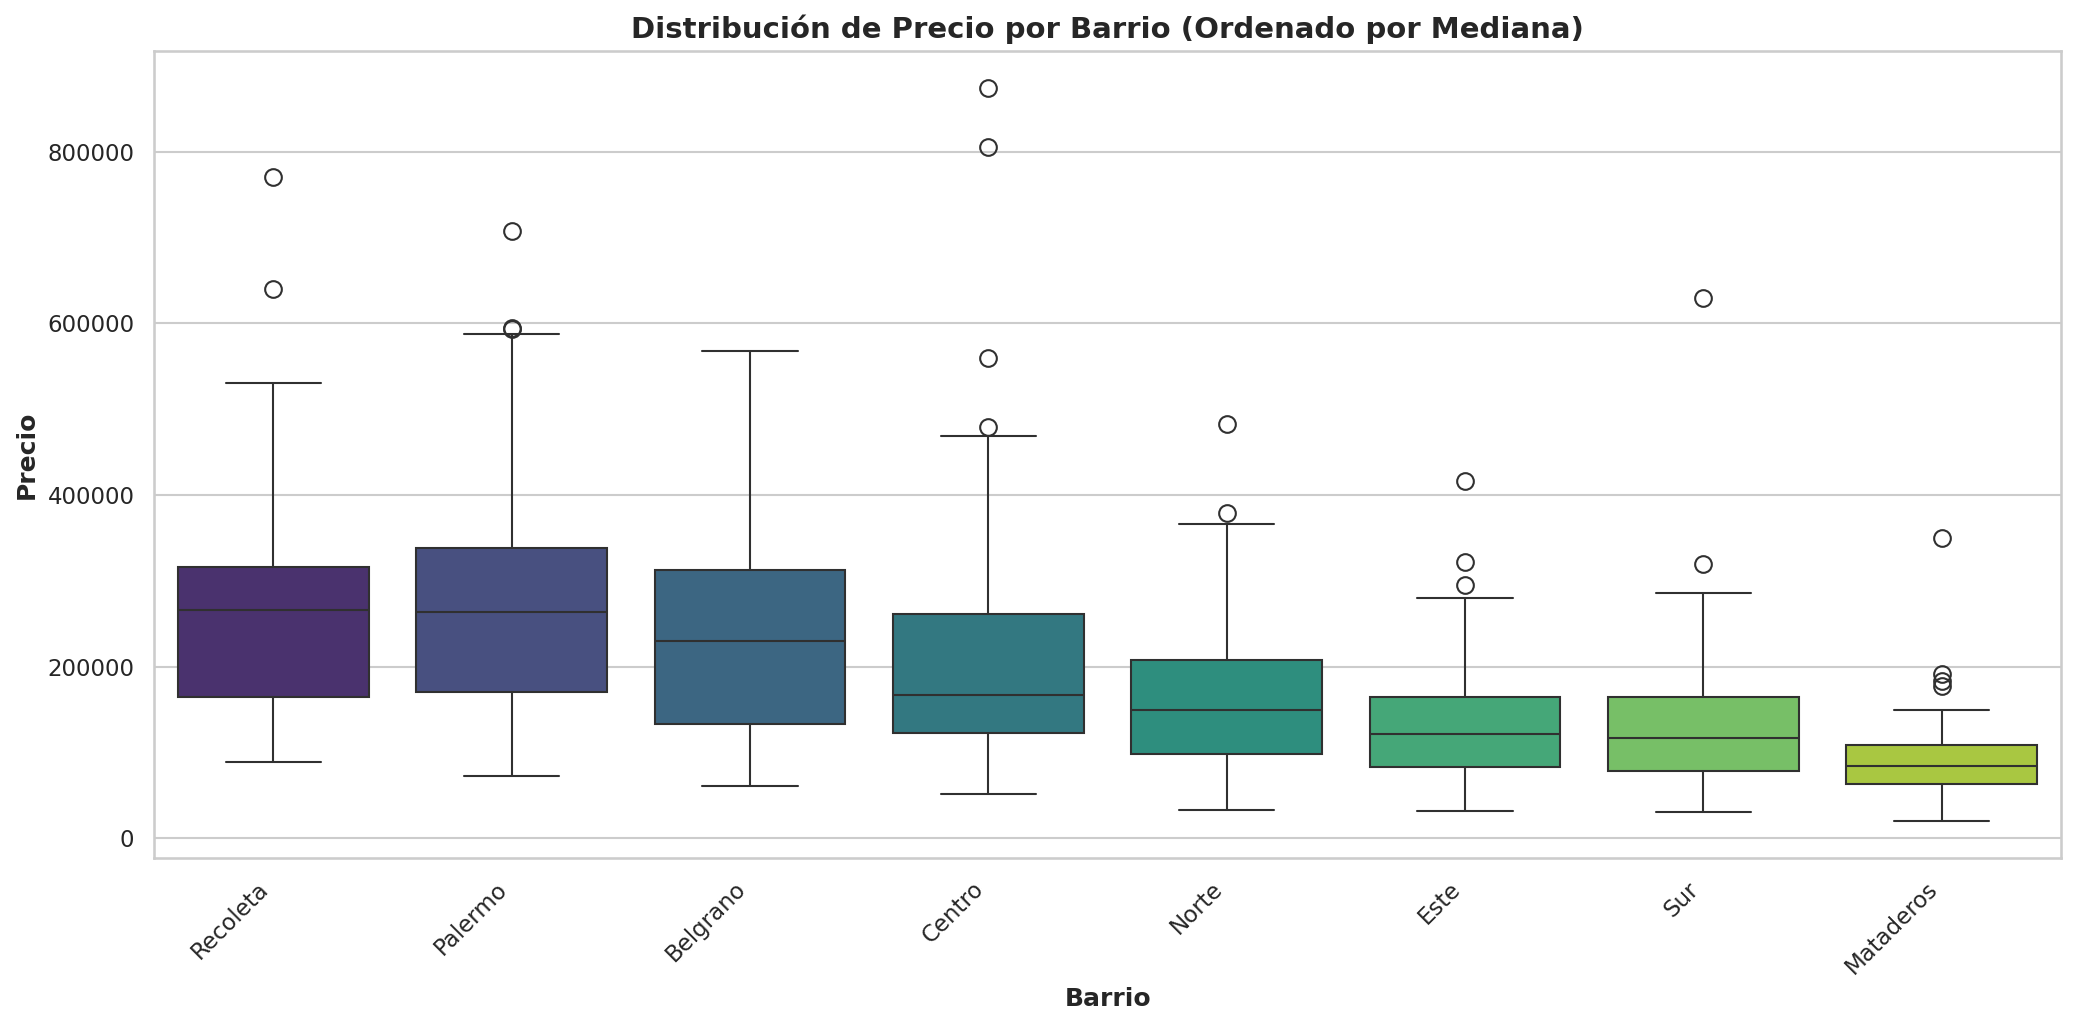

In [ ]:
# Precio mediano por barrio, ordenado
median_prices = datasetPropiedadesClean.groupby('barrio')['precio'].median().sort_values(ascending=False)
barrio_order = median_prices.index

plt.figure(figsize=(14, 7))
sns.boxplot(x='barrio', y='precio', data=datasetPropiedadesClean, order=barrio_order, palette='viridis')
plt.title('Distribución de Precio por Barrio (Ordenado por Mediana)')
plt.xlabel('Barrio')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos observar que Recoleta es el barrio con los precios promedios mas altos, lo cual tiene sentido según lo anteriormente explicado, y mataderos posee los precios mas bajos en promedio.

¿Que ocurre si la comparamos con la dataset original?

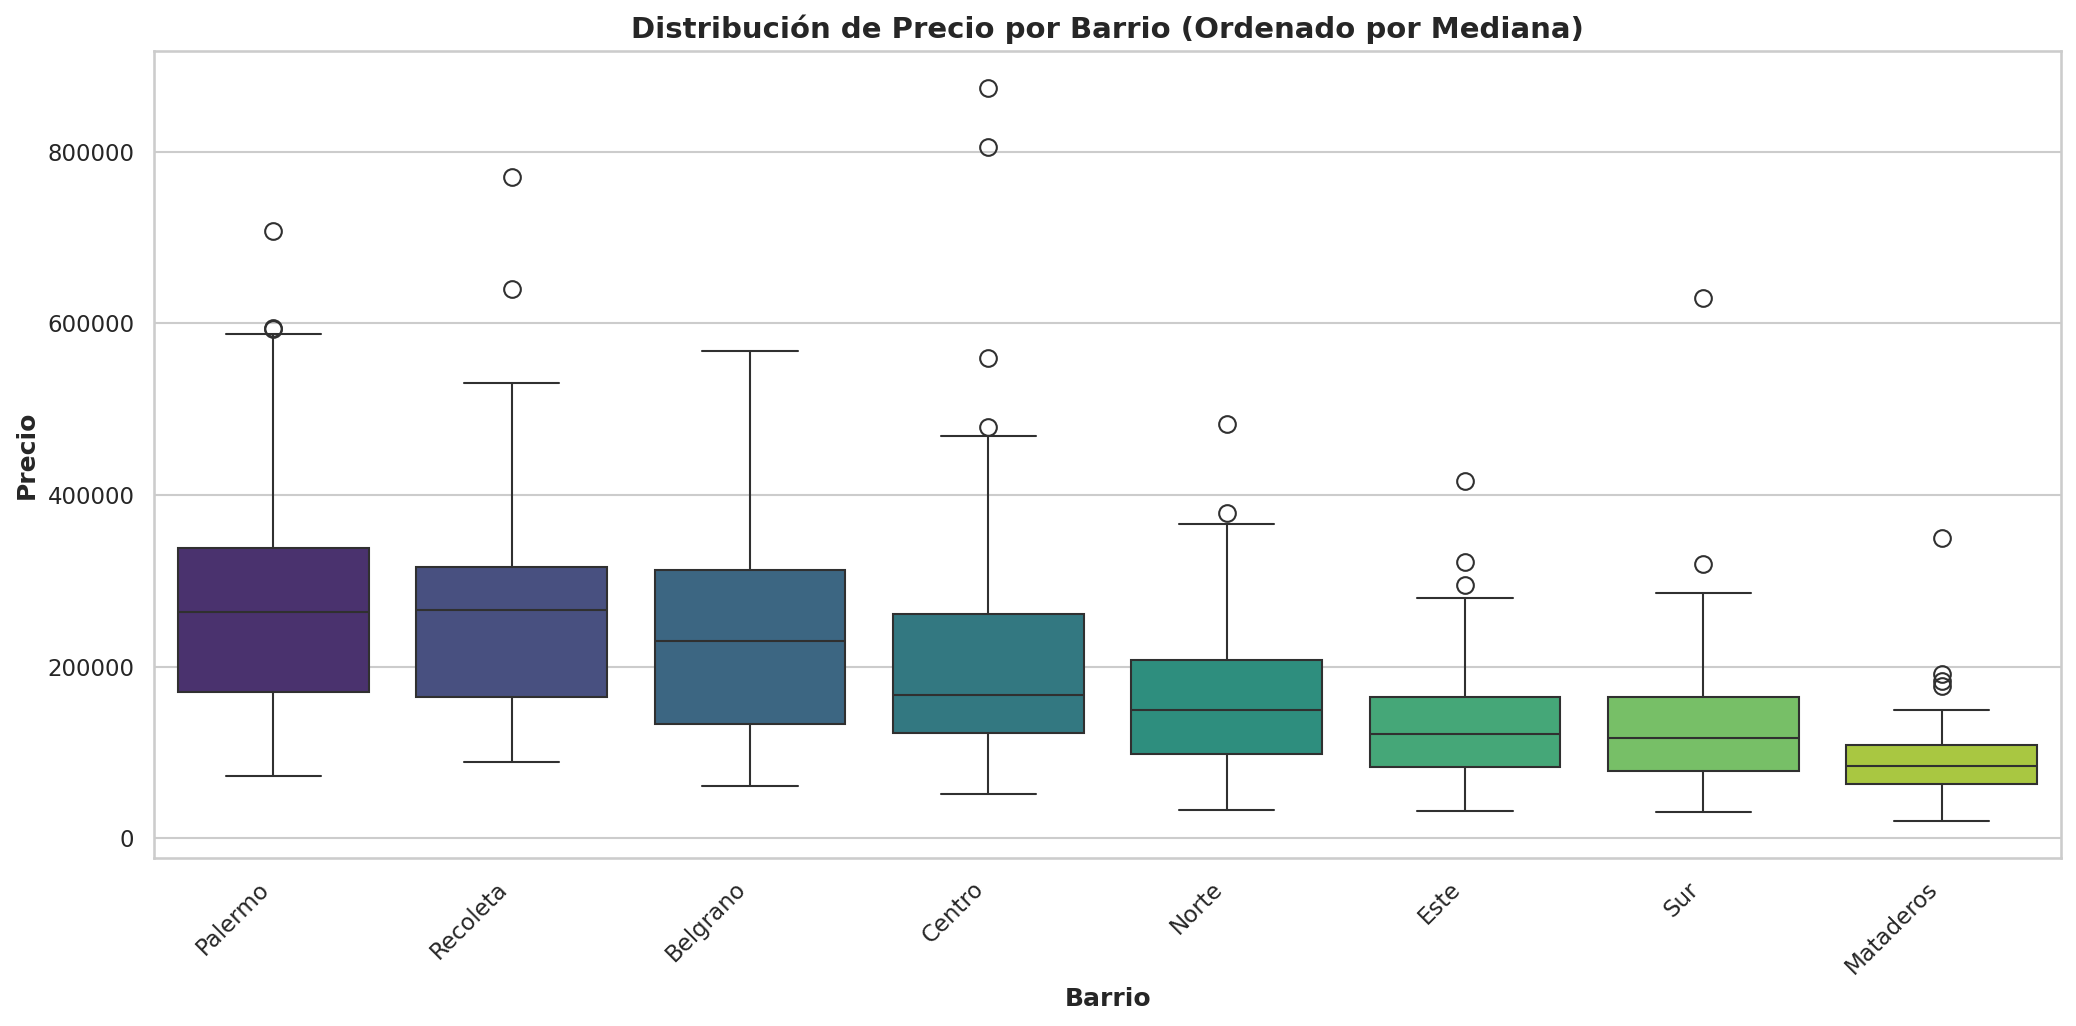

In [ ]:
# Precio mediano por barrio, ordenado
median_prices = datasetPropiedades.groupby('barrio')['precio'].median().sort_values(ascending=False)
barrio_order = median_prices.index

plt.figure(figsize=(14, 7))
sns.boxplot(x='barrio', y='precio', data=datasetPropiedadesClean, order=barrio_order, palette='viridis')
plt.title('Distribución de Precio por Barrio (Ordenado por Mediana)')
plt.xlabel('Barrio')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos observar que en este caso Palermo es el barrio mas caro, estadisticamente esto puede pasar al estar tomando de muestra datos que favorecen a un barrio o a otro, tanto Recoleta como Palermo son los barrios mas caros en la realidad.

En este caso esto ocurre al realizar una limpieza de la dataset bajo ciertos criterios, que pueden alterar el análisis estadístico que se realiza previo a la depuracion de datos.

---

#Ejercicio 2: Exploración comparativa

---
**Dataset:** `clientes_chrun.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

>Para este ejercicio se incorpora un segundo dataset, correspondiente al historial de clientes de una empresa de telecomunicaciones con información sobre cancelación del servicio (chrun). El dataset incluye variables como antigüedad del cliente, tipo de contrato, monto mensual facturado, cantidad de productos contratados y una variable binaria que indica si el cliente abandonó el servicio:
>- churn: 0 = permanece
>- churn: 1 = se fue
>
>El dataset se encuentra en el archivo adjunto denominado **"clientes_churn.csv"**.
>El objetivo es comparar ambos datasets desde el punto de vista exploratorio, desarrollando criterio sobre las particularidades de cada uno.

---
##0. Configuracion del entorno

In [248]:
#importación del dataset requerido para el enunciado
datasetChurn = pd.read_csv("/content/clientes_churn.csv")

##1. Carga y primera inspección

In [249]:
print("Primeras 10 filas del dataset:\n")
datasetChurn.head(10)

Primeras 10 filas del dataset:



,id_cliente,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,1001,42,anual,40.64,3.0,1,1,0
1,1002,16,mensual,68.57,2.0,1,0,1
2,1003,78,bianual,32.38,3.0,0,0,1
3,1004,9,anual,63.87,1.0,0,1,1
4,1005,1,mensual,68.47,1.0,1,1,0
5,1006,42,bianual,42.23,5.0,0,1,0
6,1007,45,anual,44.62,3.0,0,0,0
7,1008,49,anual,51.34,1.0,1,0,0
8,1009,4,mensual,30.19,1.0,0,1,1
9,1010,20,mensual,67.23,5.0,0,1,0


In [250]:
print(f"El dataset 'datasetChurn' tiene {len(datasetChurn)} registros.\n")
print("Tipos de datos por columna:")
print(datasetChurn.dtypes)

El dataset 'datasetChurn' tiene 1200 registros.

Tipos de datos por columna:
id_cliente               int64
antiguedad_meses         int64
contrato                object
facturacion_mensual    float64
productos              float64
soporte_tecnico          int64
tiene_fibra              int64
churn                    int64
dtype: object


Se cuentan 1200 registros, donde cada registro (fila) representa a un cliente individual identificado por un `id_cliente`.

Por otro lado, se cuentan 8 variables en total, las cuales se clasifican de la siguiente manera:
- `antiguedad_meses`, `mensual` y `productos` califican como variables numéricas.
- `contrato` y `soporte_tecnico` califican como variables categóricas
- `churn` califica como variable target u objetivo

en donde cada variable tiene un proposito distinto:

- `antiguedad_meses`: Es el tiempo (en meses que el cliente lleva con la empresa.
- `facturacion_mensual`: Es el monto que paga el cliente de cada mes.
- `productos`: Es la cantidad de servicios contratados.
- `contrato`: Define la relación legal del cliente con el servicio.
- `soporte_tecnico`: indica si cuenta con el servicio (1) o no (0).
- `tiene_fibra`: indica la tecnología de conexión (1: Fibra, 0:Otros).
-`churn`: Es la variable a predecir.

---
##2. Calidad de datos

Un primer paso que deberiamos tomar es eliminar la `id_cliente` del dataset ya que no aporta informacion importante desde el punto de vista analitico.

In [251]:
if 'id_cliente' in datasetChurn.columns:
    datasetChurn.drop(columns=['id_cliente'], inplace=True)
    print("Columna 'id_cliente' eliminada.")
else:
    print("La columna 'id_cliente' ya no existe en el dataset.")

datasetChurn.head()

Columna 'id_cliente' eliminada.


,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,42,anual,40.64,3.0,1,1,0
1,16,mensual,68.57,2.0,1,0,1
2,78,bianual,32.38,3.0,0,0,1
3,9,anual,63.87,1.0,0,1,1
4,1,mensual,68.47,1.0,1,1,0


###2.1 Valores Faltantes

In [252]:
def obtener_resumen_datos(df, nombre):
    nulos = df.isnull().sum()
    porcentaje = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({
        'Nulos': nulos,
        'Porcentaje (%)': porcentaje
    })
    return resumen

resumen_churn = obtener_resumen_datos(datasetChurn, "Churn")

print(f"--- Resumen de Datos Vacíos: Churn (Total: {len(datasetChurn)}) ---")
display(resumen_churn)

--- Resumen de Datos Vacíos: Churn (Total: 1200) ---


,Nulos,Porcentaje (%)
antiguedad_meses,0,0.0
contrato,0,0.0
facturacion_mensual,36,3.0
productos,60,5.0
soporte_tecnico,0,0.0
tiene_fibra,0,0.0
churn,0,0.0



Existen valores nulos en tres variables:
- `facturacion_mensual`: **36 valores faltantes (3%)**.
- `productos`: **60 valores faltantes (5%)**.

###2.2 Detección de valores inconsistentes o erróneos

Ahora vamos a verificar si existen valores negativos en las columnas numéricas que no deberían tenerlos, como `antiguedad_meses`, `facturacion_mensual` y `productos`.

In [253]:
columnas_numericas_churn = ['antiguedad_meses', 'facturacion_mensual', 'productos']

print("Verificación de valores negativos en Dataset Churn:")
for col in columnas_numericas_churn:
    if col in datasetChurn.columns:
        valores_negativos = datasetChurn[datasetChurn[col] < 0]
        if not valores_negativos.empty:
            print(f"- Se encontraron {len(valores_negativos)} valores negativos en '{col}'.")
            display(valores_negativos)
        else:
            print(f"- No hay valores negativos en '{col}'.")

Verificación de valores negativos en Dataset Churn:
- No hay valores negativos en 'antiguedad_meses'.
- No hay valores negativos en 'facturacion_mensual'.
- No hay valores negativos en 'productos'.


Tambien debemos verificar que no existan valores indeseados en las variables categoricas `contrato`, `soporte_tecnico`, `tiene_fibra` y el target `churn`.

In [254]:
print("Distribución de valores en la columna 'contrato':")
conteo_contrato = datasetChurn['contrato'].value_counts(dropna=False)
print(conteo_contrato)

# Verificamos si hay valores que no sean los esperados (anual, mensual, bianual)
valores_esperados = ['anual', 'mensual', 'bianual']
valores_extranos = datasetChurn[~datasetChurn['contrato'].isin(valores_esperados)]

if not valores_extranos.empty:
    print(f"\nSe detectaron {len(valores_extranos)} registros con valores inconsistentes o nulos en 'contrato':")
    display(valores_extranos['contrato'].unique())
else:
    print("\nNo se detectaron valores extraños en la columna 'contrato'. Todos coinciden con las categorías esperadas.")

Distribución de valores en la columna 'contrato':
contrato
mensual    653
anual      365
bianual    182
Name: count, dtype: int64

No se detectaron valores extraños en la columna 'contrato'. Todos coinciden con las categorías esperadas.


In [255]:
variables_binarias = ['soporte_tecnico', 'tiene_fibra', 'churn']

for col in variables_binarias:
    print(f"Distribución de valores en '{col}':")
    conteo = datasetChurn[col].value_counts(dropna=False)
    print(conteo)

    # Verificar si hay valores distintos de 0 o 1
    valores_atipicos = datasetChurn[~datasetChurn[col].isin([0, 1])]
    if not valores_atipicos.empty:
        print(f"¡Atención! Se detectaron valores extraños en '{col}': {valores_atipicos[col].unique()}")
    else:
        print(f"La columna '{col}' es consistente (solo 0 y 1).")
    print("-" * 30)

Distribución de valores en 'soporte_tecnico':
soporte_tecnico
1    671
0    529
Name: count, dtype: int64
La columna 'soporte_tecnico' es consistente (solo 0 y 1).
------------------------------
Distribución de valores en 'tiene_fibra':
tiene_fibra
1    708
0    492
Name: count, dtype: int64
La columna 'tiene_fibra' es consistente (solo 0 y 1).
------------------------------
Distribución de valores en 'churn':
churn
0    808
1    392
Name: count, dtype: int64
La columna 'churn' es consistente (solo 0 y 1).
------------------------------


### Comparacion de calidad de datos
A simple vista se puede ver que este dataset tiene un menor porcentaje de valores nulos que el de propiedades, por lo que se puede decir que es mas limpio en cuanto a calidad de datos.

###2.3 Decisiones a tomar frente a valores nulos

En el caso de `facturacion_mensual`, decidimos eliminar el 3% de filas con valores nulos ya que creemos que es un factor importante a la hora de decidir si dar de baja un servicio de telecomunicaciones y no supone una gran perdida de datos. Por otro lado, en el caso de la variable `productos` decidimos rellenar los huecos con la **moda** de la distribucion al ser un dato que no creemos que pueda sesgar la muestra y ademas ser una pequña cantidad representando solo el 5% de las entradas.

In [256]:
# 1. Eliminar filas con nulos en 'facturacion_mensual'
datasetChurnClean = datasetChurn.dropna(subset=['facturacion_mensual'])

# 2. Rellenar nulos en 'productos' con la moda
moda_productos = datasetChurnClean['productos'].mode()[0]
datasetChurnClean['productos'] = datasetChurnClean['productos'].fillna(moda_productos)

print(f"Moda utilizada para 'productos': {moda_productos}")
print(f"Tamaño del dataset original: {len(datasetChurn)}")
print(f"Tamaño del dataset limpio: {len(datasetChurnClean)}")

print("\nValores nulos restantes:")
print(datasetChurnClean.isnull().sum())

Moda utilizada para 'productos': 2.0
Tamaño del dataset original: 1200
Tamaño del dataset limpio: 1164

Valores nulos restantes:
antiguedad_meses       0
contrato               0
facturacion_mensual    0
productos              0
soporte_tecnico        0
tiene_fibra            0
churn                  0
dtype: int64


---
##3 Estadistica Descriptiva

In [257]:
# Seleccionar columnas numéricas que no sean binarias (0 y 1)
columnas_numericas = [col for col in datasetChurnClean.select_dtypes(include=['number']).columns
                      if not set(datasetChurnClean[col].unique()).issubset({0, 1})]

# Calcular la media y la desviación estándar
valores_media = datasetChurnClean[columnas_numericas].mean()
valores_desviacion = datasetChurnClean[columnas_numericas].std()

# CV = Desviación Estándar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados
cv_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
}).sort_values(by='Coeficiente de Variación', ascending=False)

display(cv_df)

,Media,Desviación Estándar,Coeficiente de Variación
antiguedad_meses,30.518900,24.102079,0.789743
productos,2.451890,1.177427,0.480212
facturacion_mensual,63.840275,21.955551,0.343914


La alta variabilidad de la antiguedad probablemente se deba a que hay tanto clientes nuevos como clientes fieles que hace años consumen el servicio.

In [258]:
# Calcular la media y la mediana para cada columna numérica
median_values = datasetChurnClean[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - median_values).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': median_values,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(diferencia_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
antiguedad_meses,30.518900,24.5,6.018900,19.721878
productos,2.451890,2.0,0.451890,18.430273
facturacion_mensual,63.840275,62.4,1.440275,2.256060


Podemos deducir de la diferencia entre la media y la mediana que las distribuciones de `antiguedad_meses` y `productos` tienen asimetria positiva, mientras que `facturacion_mensual` solo esta levemente sesgada hacia la derecha.

---
## 4. Distribuciones, outliers y balance de categorias

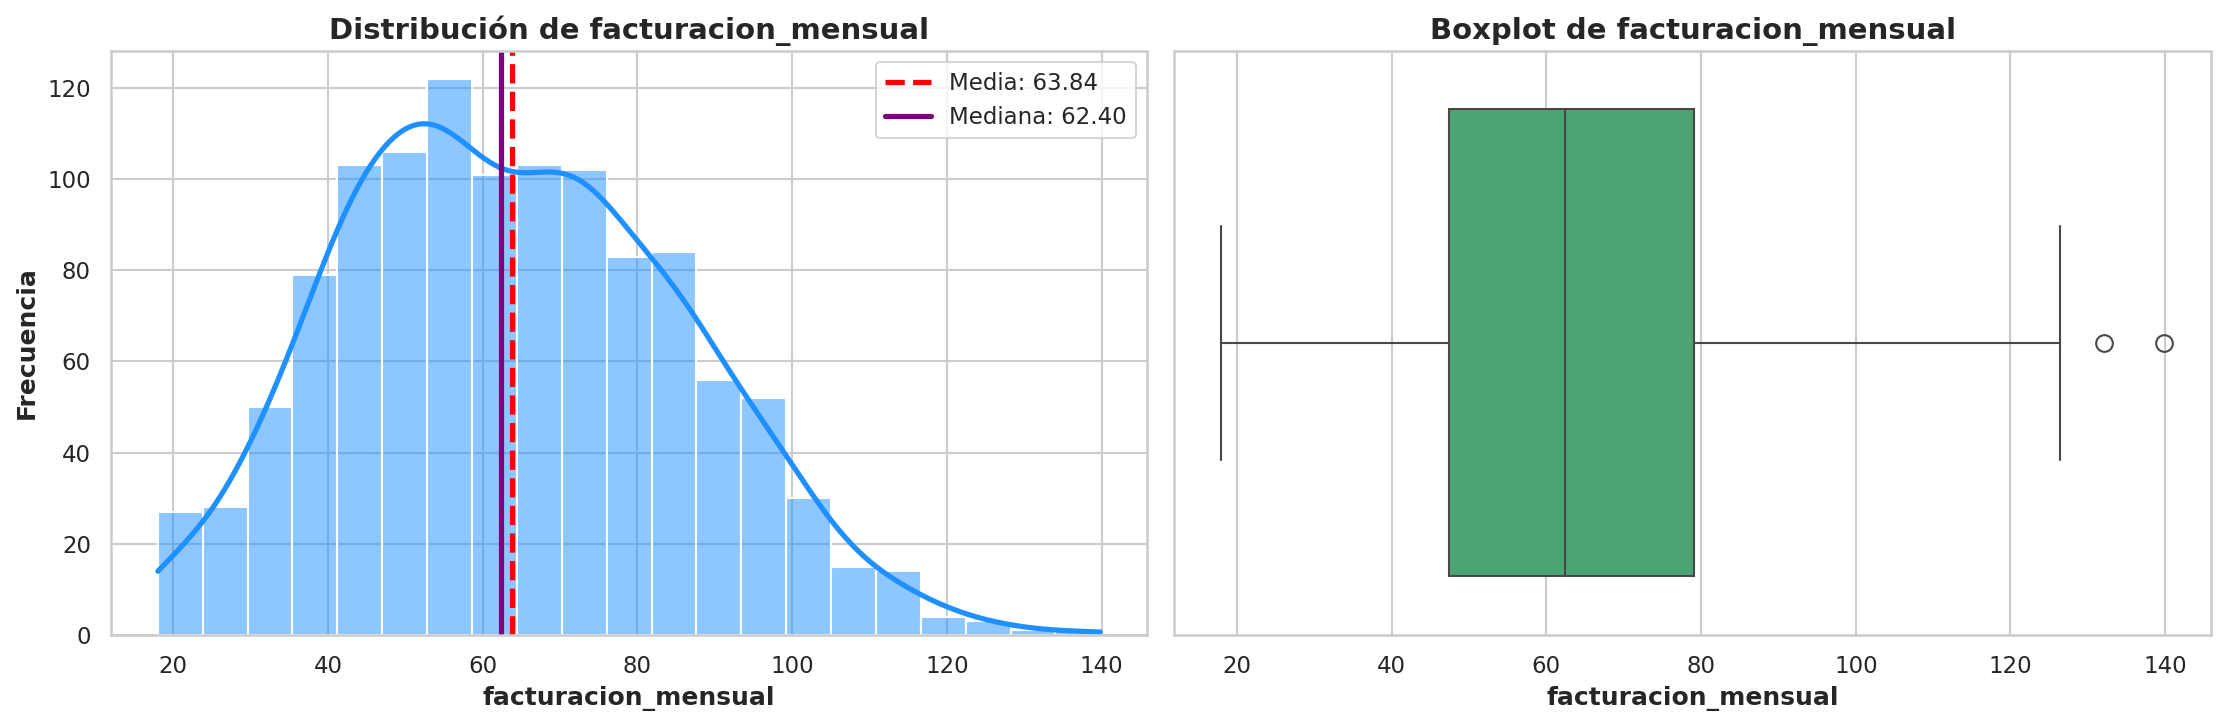

In [259]:
var = 'facturacion_mensual'
data_series = datasetChurnClean[var]

# Configuramos la figura con subplots (1 fila para una variable)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# --- 1. HISTOGRAMA ---
sns.histplot(data_series, kde=True, ax=axes[0], color='dodgerblue')
mean_val = data_series.mean()
median_val = data_series.median()
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
axes[0].axvline(median_val, color='purple', linestyle='-', label=f'Mediana: {median_val:.2f}')
axes[0].set_title(f'Distribución de {var}')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# --- 2. BOXPLOT ---
sns.boxplot(x=data_series, ax=axes[1], color='mediumseagreen')
axes[1].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

Podemos confirmar con este histograma que la distribucion de `facturacion_mensual` es practicamente simetrica. A su vez, observamos en el diagrama de caja y bigotes que no hay un gran volumen de datos atipicos.

In [260]:
top_10_facturacion = datasetChurnClean.nlargest(10, 'facturacion_mensual')
print("Top 10 clientes con mayor facturación mensual:")
display(top_10_facturacion)

Top 10 clientes con mayor facturación mensual:


,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
521,7,mensual,139.83,2.0,1,1,1
36,3,mensual,132.15,2.0,1,1,1
988,2,mensual,126.41,4.0,1,1,0
1049,58,mensual,125.77,3.0,1,1,0
568,34,mensual,123.55,2.0,1,0,1
372,6,mensual,121.24,1.0,1,1,1
704,13,mensual,120.75,3.0,0,0,1
444,19,mensual,119.64,4.0,1,0,0
970,24,mensual,119.02,5.0,1,0,1
230,14,mensual,116.30,2.0,0,0,1


Se puede apreciar que los valores mas altos de `facturacion_mensual` no son datos exageradamentes fuera de lo normal (como lo seria 300, evidenciando un error de humano de agregar un cero). Ademas, se puede agregar que los valores con mayor facturacion y pocos productos dieron de baja el servicio, este puede ser un posible patron a analizar.

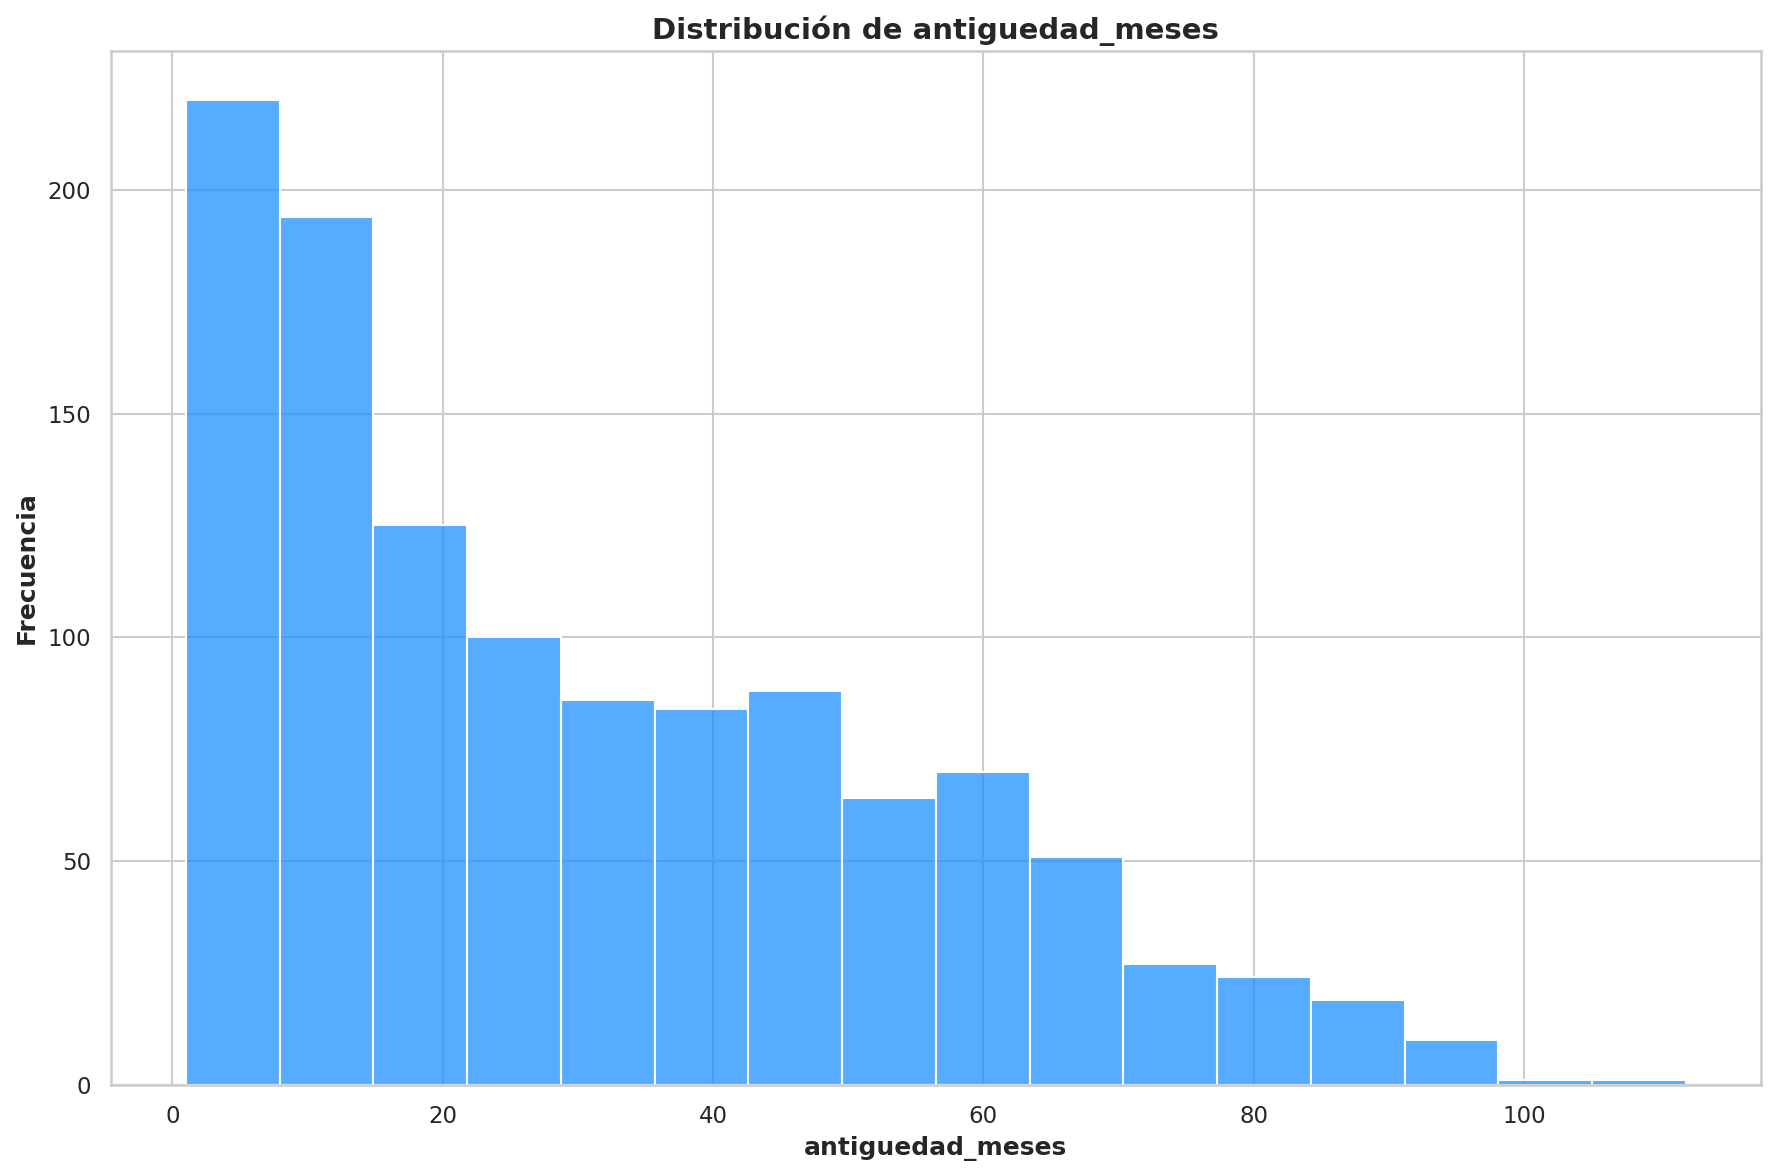

In [261]:
# Configuramos la figura con subplots para una sola variable
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
var = 'antiguedad_meses'

# Histograma
sns.histplot(datasetChurnClean[var], ax=axes, color='dodgerblue')
axes.set_title(f'Distribución de {var}')
axes.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se puede observar en la distribucion de `facturacion_mensual` que hay un claro sesgo hacia la derehca, esto significa realmente que la empresa esta creciendo y hay muchos clientes probando el servicio por primera vez. Una forma facil de analizar si los datos atipicos son congruentes seria saber en que fecha comenzo la actividad de la empresa, pero en general podemos decir que tienen sentido ya que las empresas comienzan con pocos clientes y algunos de esos pocos permanecen leales con los años.

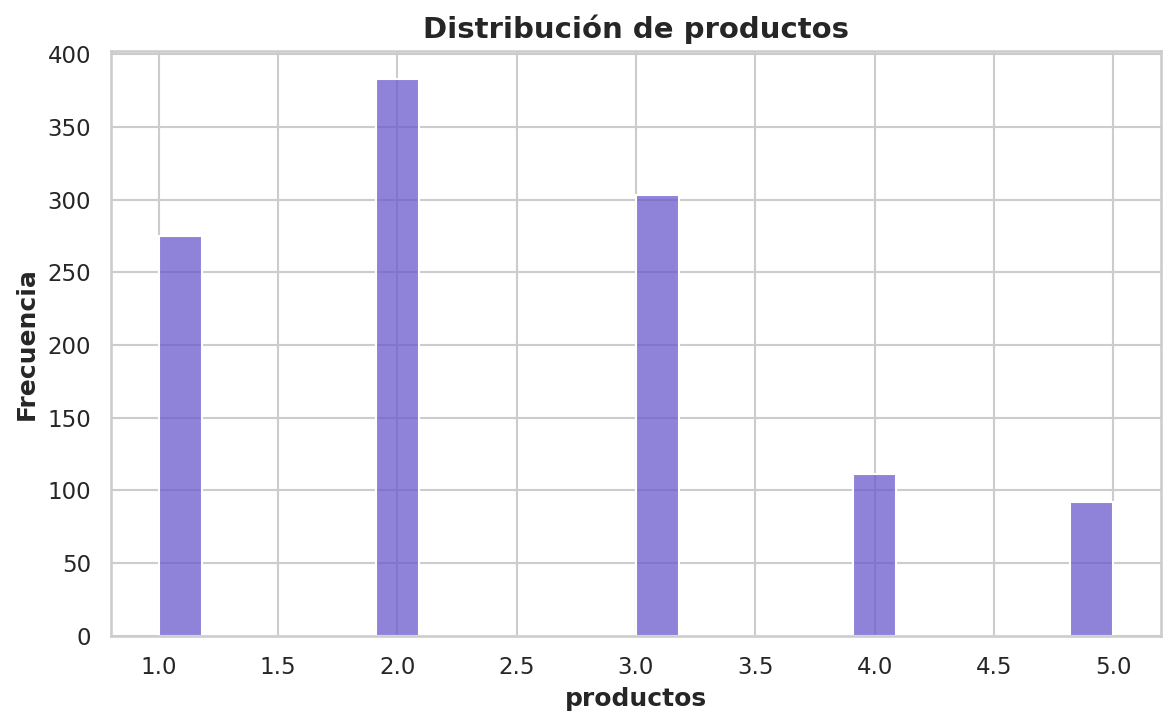

In [262]:
# Configuramos la figura con un solo plot para el histograma de productos
plt.figure(figsize=(8, 5))
var = 'productos'

# Histograma
sns.histplot(datasetChurnClean[var], color='slateblue')
plt.title(f'Distribución de {var}')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

En el caso de `productos`, vemos gracias a la asimetria positiva en la grafica una notable preferencia de los clientes por pagar entre 1 y 3 productos, aunque otros tengan la necesidad de tener 4 o 5.

En el dataset de telecomunicaciones tambien existen múltiples variables categóricas. Identificando a `contrato` como una variable categórica nominal (con valores en texto: mensual, anual, bianual). Además, existen variables categóricas binarias que ya se encuentran codificadas numéricamente como `soporte_tecnico` (1/0) y `tiene_fibra` (1/0).

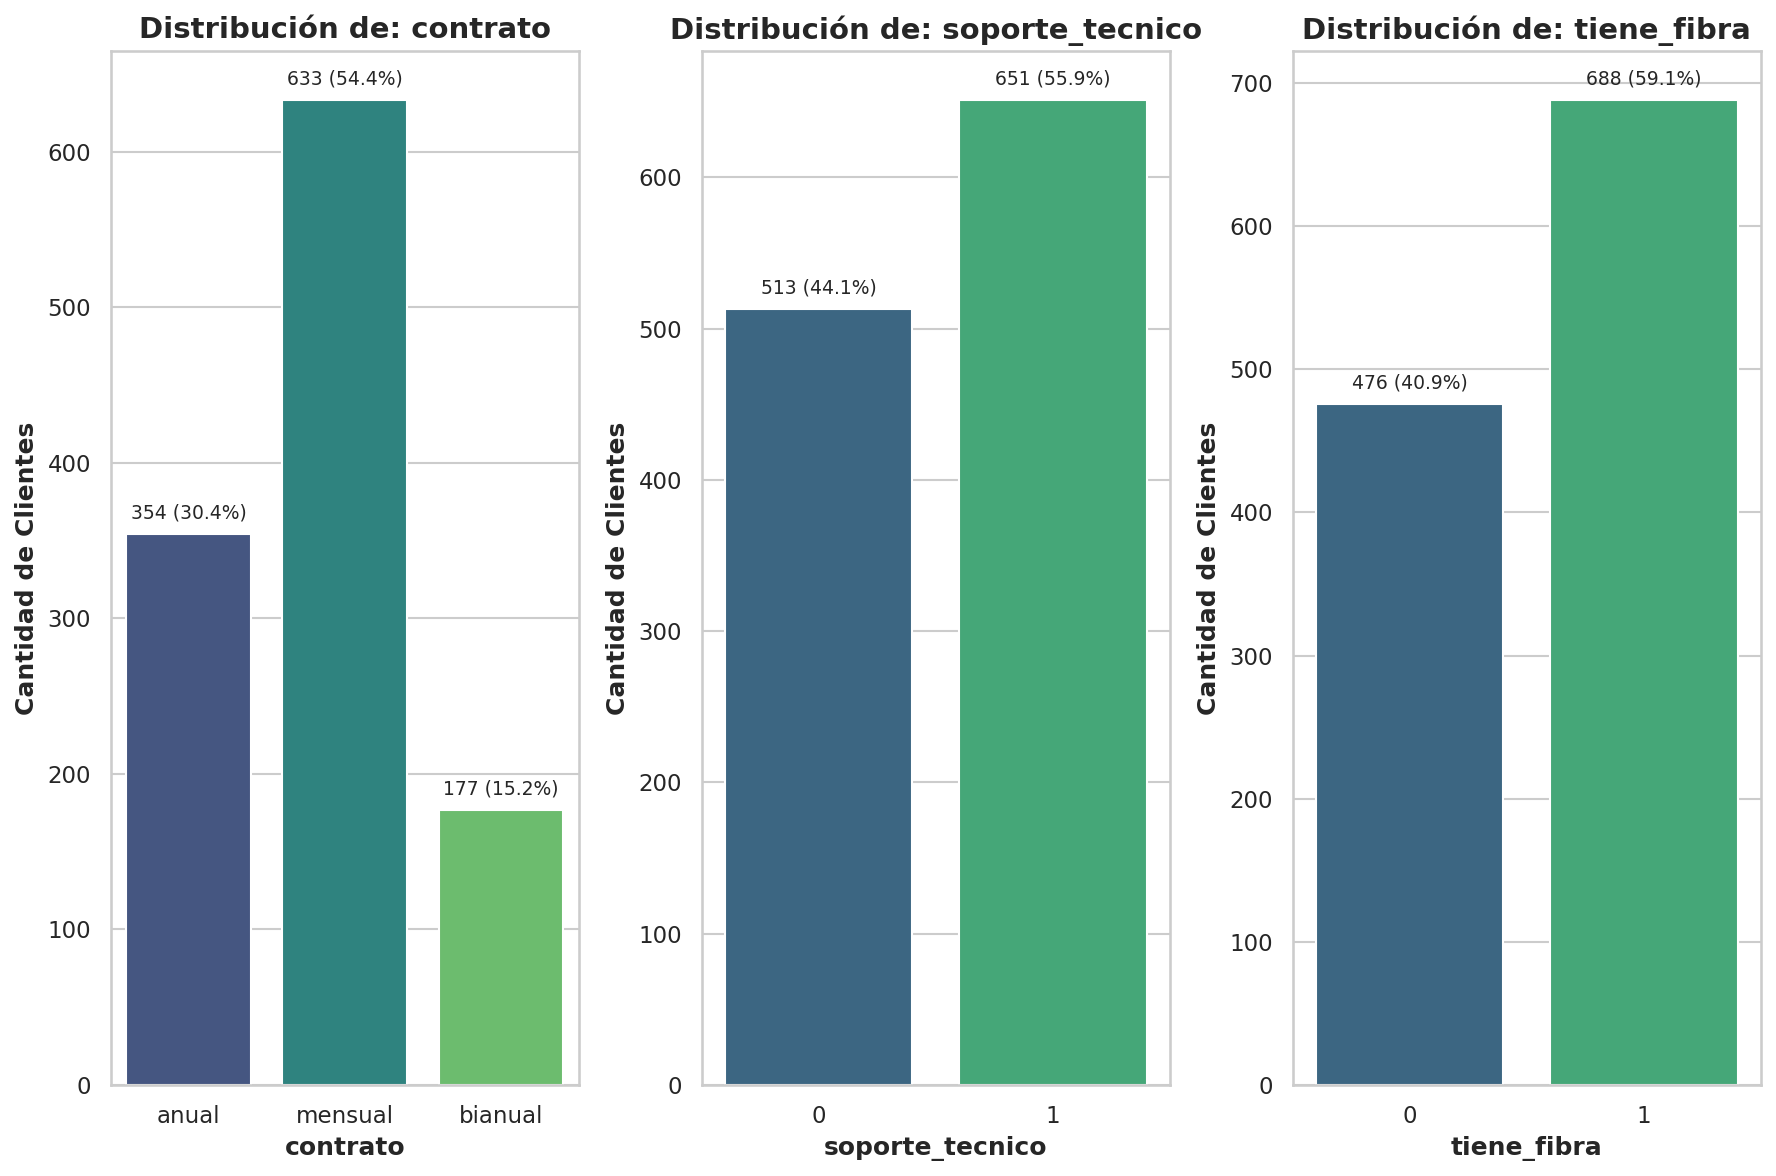

In [263]:
# Definimos cuáles son nuestras variables categóricas predictoras
variables_cat = ['contrato', 'soporte_tecnico', 'tiene_fibra']

# Preparamos una figura con 3 subgráficos
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 8))

total = len(datasetChurnClean)

# Iteramos para crear un gráfico de barras por cada variable
for i, col in enumerate(variables_cat):
    sns.countplot(data=datasetChurnClean, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de: {col}')
    axes[i].set_ylabel('Cantidad de Clientes')

    # Agregar etiquetas de cantidad y porcentaje
    for p in axes[i].patches:
        height = p.get_height()
        percentage = (height / total) * 100
        axes[i].annotate(f'{int(height)} ({percentage:.1f}%)',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center',
                         xytext=(0, 10),
                         textcoords='offset points',
                         fontsize=9)

# Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

Al generar los gráficos de barras para observar la distribución de frecuencias, se detecta que la variable `contrato` es la que presenta una dominancia visual más marcada. La categoría "mensual" agrupa a mas de la mitad de los clientes (54,4%), superando a las opciones "anual" (30,4%) y "bianual" (15,2%). En contraste, las variables binarias como `tiene_fibra` y `soporte_tecnico` presentan distribuciones visualmente más equilibradas, rondando una proporción cercana al 60% - 40%.

Ahora realizaremos un analisis del balance de las clases de `churn`

--- CANTIDAD DE CLIENTES ---
churn
0    787
1    377
Name: count, dtype: int64

--- PROPORCIÓN EXACTA (%) ---
churn
0    67.61
1    32.39
Name: proportion, dtype: float64


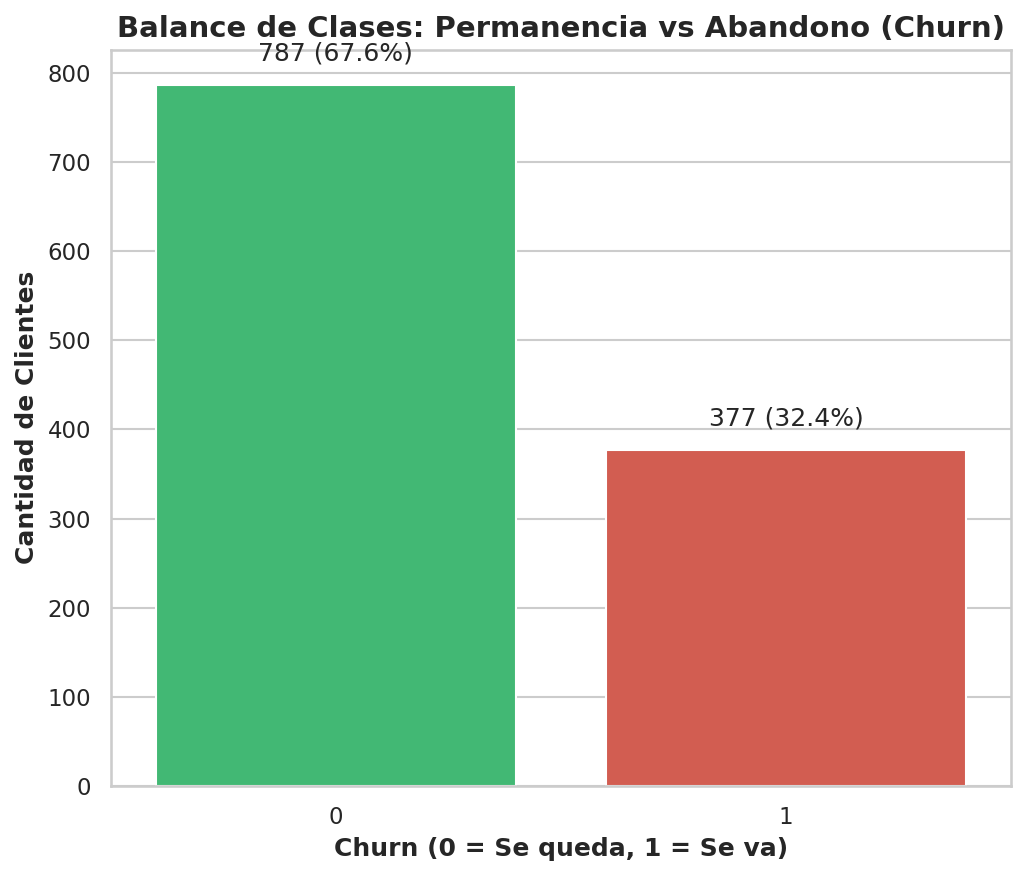

In [264]:
# 1. Análisis numérico exacto
conteo_real = datasetChurnClean['churn'].value_counts()
proporcion = datasetChurnClean['churn'].value_counts(normalize=True) * 100

print("--- CANTIDAD DE CLIENTES ---")
print(conteo_real)
print("\n--- PROPORCIÓN EXACTA (%) ---")
print(proporcion.round(2))

# 2. Gráfico para analizar visualmente el balance
plt.figure(figsize=(7, 6))
ax = sns.countplot(data=datasetChurnClean, x='churn', palette=['#2ecc71', '#e74c3c'])

# Configuramos las etiquetas del gráfico
plt.title('Balance de Clases: Permanencia vs Abandono (Churn)')
plt.xlabel('Churn (0 = Se queda, 1 = Se va)')
plt.ylabel('Cantidad de Clientes')

# Agregamos los numeritos y porcentajes arriba de las barras
total = len(datasetChurnClean)
for p in ax.patches:
    height = p.get_height()
    pct = (height / total) * 100
    ax.annotate(f'{int(height)} ({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 15),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Al analizar la variable objetivo `churn`, comprobamos numéricamente y visualmente que las clases **no** se encuentran balanceadas. Existe una clara predominancia de la clase 0 (clientes que permanecen).


Sobre un total de 1200 instancias, 808 clientes decidieron quedarse y 392 decidieron darse de baja. Esto significa que el 32,76% de los clientes abandonó el servicio, frente a un 67,33% que lo mantuvo.

Esto representa un caso de desbalance moderado (una relación de 2 a 1 a favor de la clase mayoritaria).

Un desbalance importante de calses al momento de entrenar un modelo de clasificación implica un alto riesgo de generar un sesgo hacia la clase mayoritaria. El algoritmo, en su intento por minimizar el error global, aprenderá que predecir siempre la clase dominante es la estrategia más "segura".

Como consecuencia, el modelo perderá sensibilidad y fracasará en su objetivo principal, el cual es detectar los casos de la clase minoritaria (que suele ser el evento de interés comercial, en este contexto, predecir exactamente qué cliente hará churm).

En este caso, la evaluación debe basarse en el análisis de la Matriz de confusión y usar metricas especiales:

- **Sensibilidad**: Fundamental para saber qué el porcentaje del total de clientes que realmente iban a abandonar se lograron identificar a tiempo.
- **Presición**: Útil para medir la confiabilidad de las alarmas del modelo evitando así malgastar el presupuesto de retención de falsos positivos.

##5. Relaciones entre variables

In [265]:
# Definir el orden lógico de los contratos
orden_contrato = {"mensual": 0, "anual": 1, "bianual": 2}

# Aplicar el mapeo y reemplazar la columna original
datasetChurnClean['contrato'] = datasetChurnClean['contrato'].map(orden_contrato)

print("Encoding aplicado y columna reemplazada satisfactoriamente. Conteo de valores:")
print(datasetChurnClean['contrato'].value_counts())
datasetChurnClean.head()

Encoding aplicado y columna reemplazada satisfactoriamente. Conteo de valores:
contrato
0    633
1    354
2    177
Name: count, dtype: int64


,antiguedad_meses,contrato,facturacion_mensual,productos,soporte_tecnico,tiene_fibra,churn
0,42,1,40.64,3.0,1,1,0
1,16,0,68.57,2.0,1,0,1
2,78,2,32.38,3.0,0,0,1
3,9,1,63.87,1.0,0,1,1
4,1,0,68.47,1.0,1,1,0


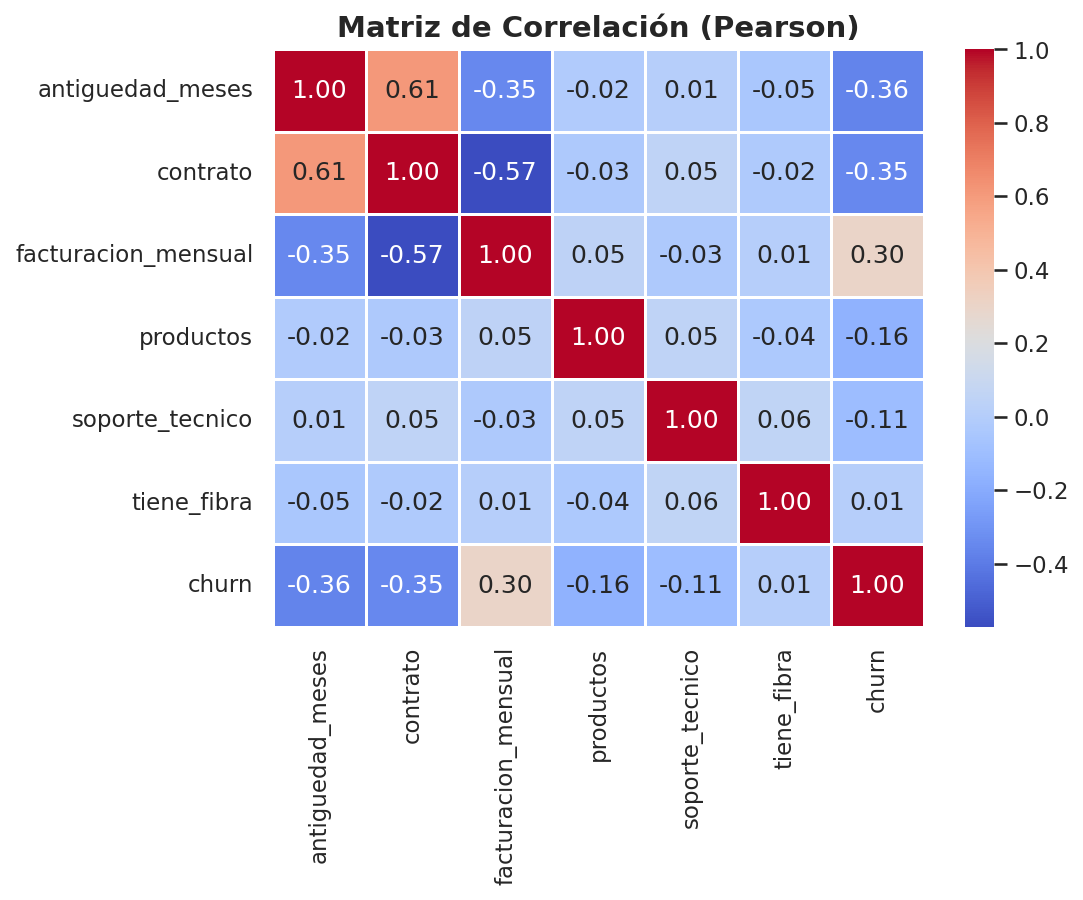

In [266]:
dataset_encoded = datasetChurnClean.copy()
le = LabelEncoder()

# Codificamos las variables categóricas, se pasa a numeros temporales debido a que aplicar la correlación estandar
# se trabaja con valores numéricos
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(7, 5))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

Podemos ver que segun la matriz de correlacion de pearson solamente hay una fuerte correlacion entre contrato y antiguedad en meses y que la facturacion mensual tiene una leve correlacion con nuestro *target*, el churn.

Ademas, en base a las pocas correlaciones que tienen las variables `fibra_optica` y `soporte_tecnico` con el resto de *features* y el *target* `churn`, se puede considerar eliminarlas del dataset para reducir la complejidad de este.

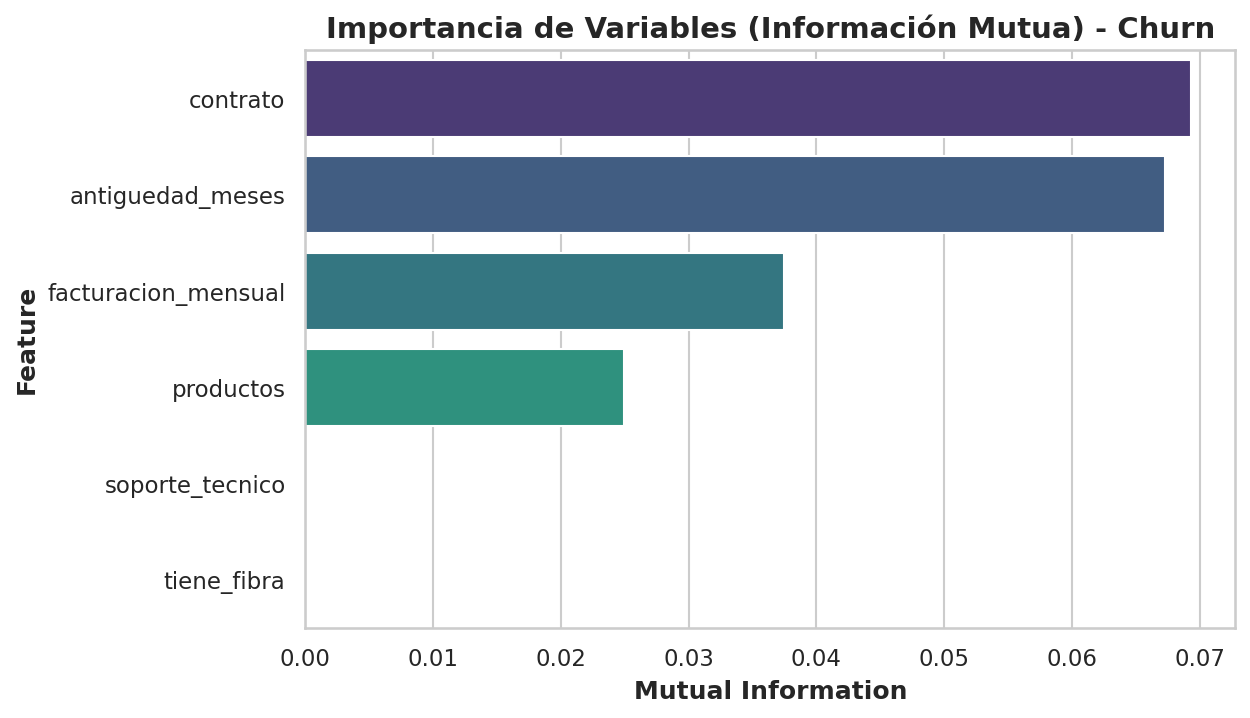

In [267]:
from sklearn.feature_selection import mutual_info_regression

X_ccs = datasetChurnClean.drop('churn', axis=1)
y_ccs = datasetChurnClean['churn']

# Calculamos MI para todas las características
mi_scores = mutual_info_regression(X_ccs, y_ccs, random_state=42)

df_mi = pd.DataFrame({
    'Feature': X_ccs.columns,
    'Mutual Information': mi_scores
}).sort_values(by='Mutual Information', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Mutual Information', y='Feature', data=df_mi, palette='viridis')
plt.title("Importancia de Variables (Información Mutua) - Churn")
plt.show()

Analizando la informacion mutua de `soporte_tecnico` y `tiene_fibra` y su poca correlacion en la matriz podemos confirmar que solo representan ruido para nuestro analisis.

In [268]:
# Eliminación de columnas con baja importancia según el análisis de información mutua
columnas_a_eliminar = ['soporte_tecnico', 'tiene_fibra']
datasetChurnClean = datasetChurnClean.drop(columns=columnas_a_eliminar)

print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Columnas restantes en datasetChurnClean: {datasetChurnClean.columns.tolist()}")
datasetChurnClean.head()

Columnas eliminadas: ['soporte_tecnico', 'tiene_fibra']
Columnas restantes en datasetChurnClean: ['antiguedad_meses', 'contrato', 'facturacion_mensual', 'productos', 'churn']


,antiguedad_meses,contrato,facturacion_mensual,productos,churn
0,42,1,40.64,3.0,0
1,16,0,68.57,2.0,1
2,78,2,32.38,3.0,1
3,9,1,63.87,1.0,1
4,1,0,68.47,1.0,0


Ahora analizaremos mas a fondo las variables relevantes.

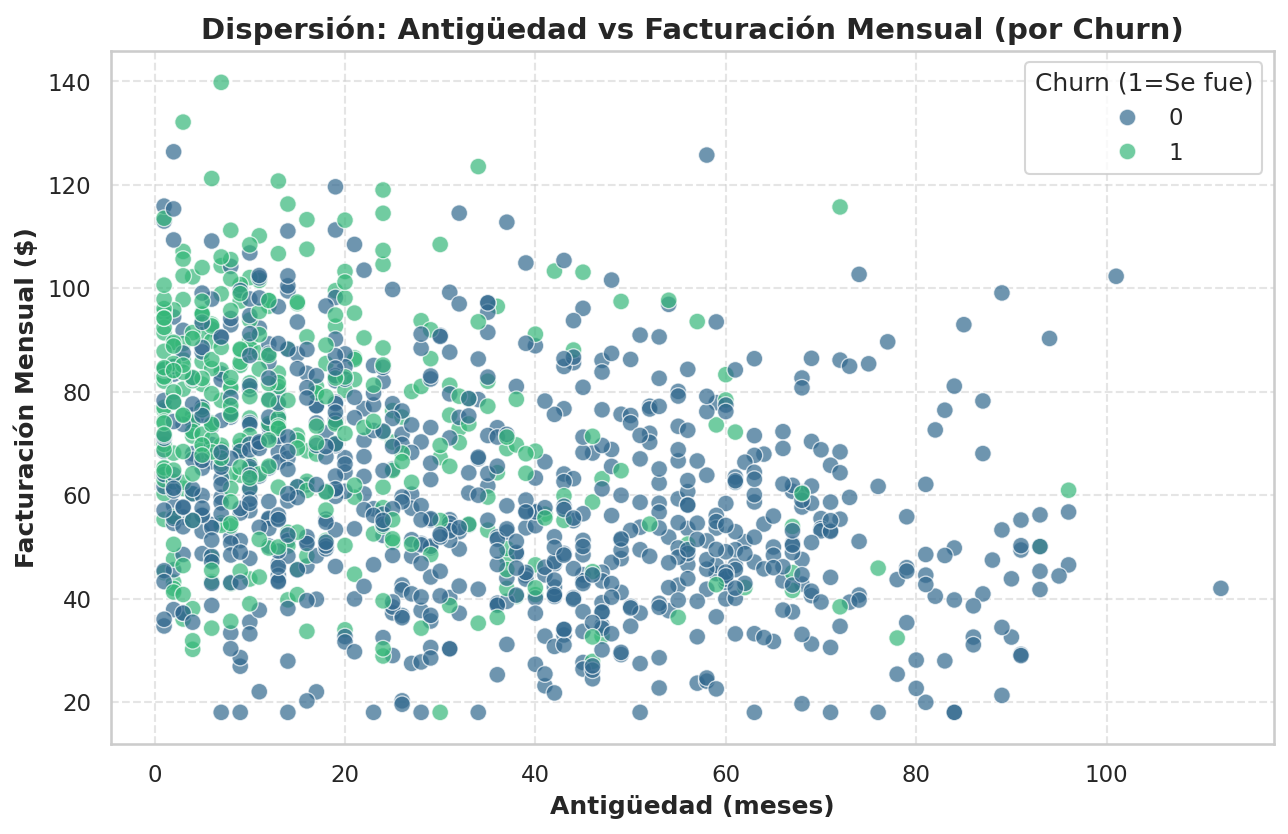

In [269]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=datasetChurnClean, x='antiguedad_meses', y='facturacion_mensual', hue='churn', palette='viridis', alpha=0.7)
plt.title('Dispersión: Antigüedad vs Facturación Mensual (por Churn)')
plt.xlabel('Antigüedad (meses)')
plt.ylabel('Facturación Mensual ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Churn (1=Se fue)')
plt.show()

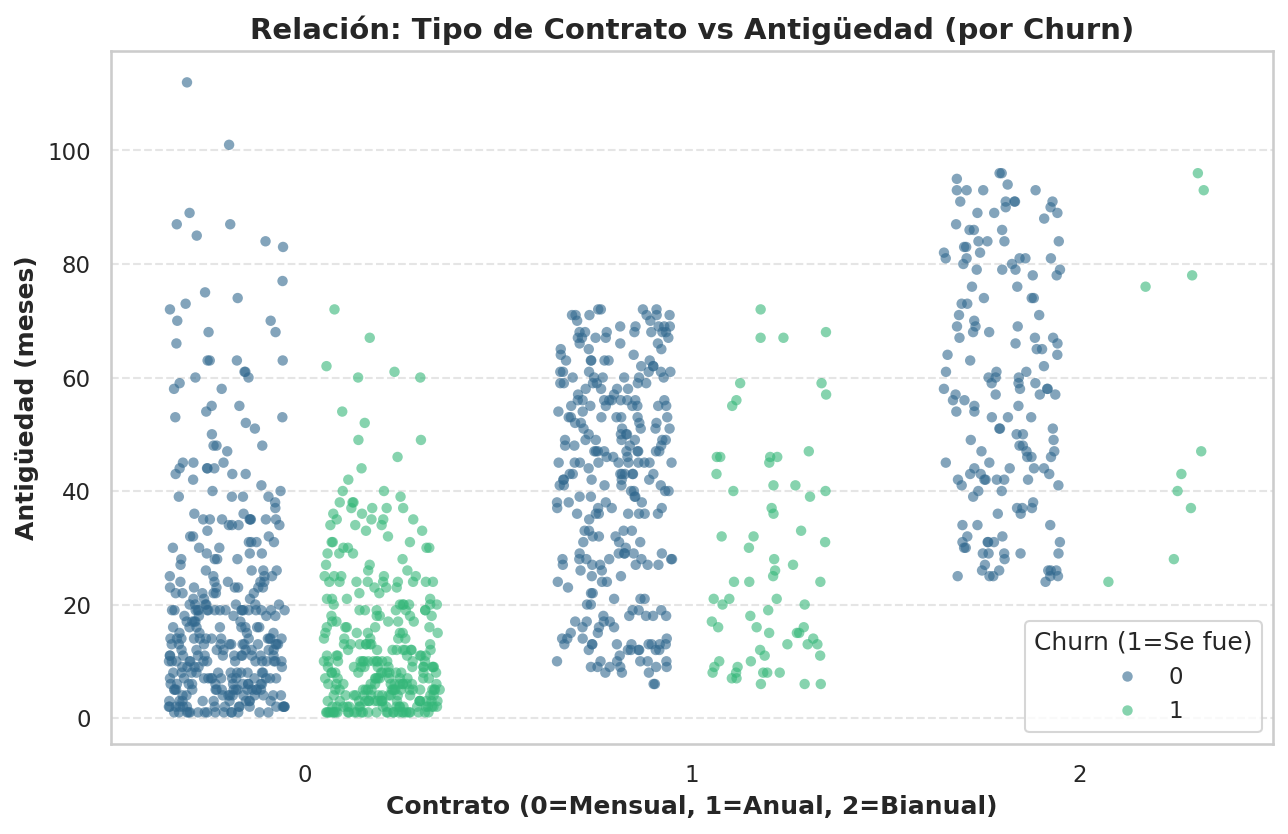

In [270]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.stripplot(data=datasetChurnClean, x='contrato', y='antiguedad_meses', hue='churn',
              palette='viridis', dodge=True, alpha=0.6, jitter=0.3)
plt.title('Relación: Tipo de Contrato vs Antigüedad (por Churn)')
plt.xlabel('Contrato (0=Mensual, 1=Anual, 2=Bianual)')
plt.ylabel('Antigüedad (meses)')
plt.legend(title='Churn (1=Se fue)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

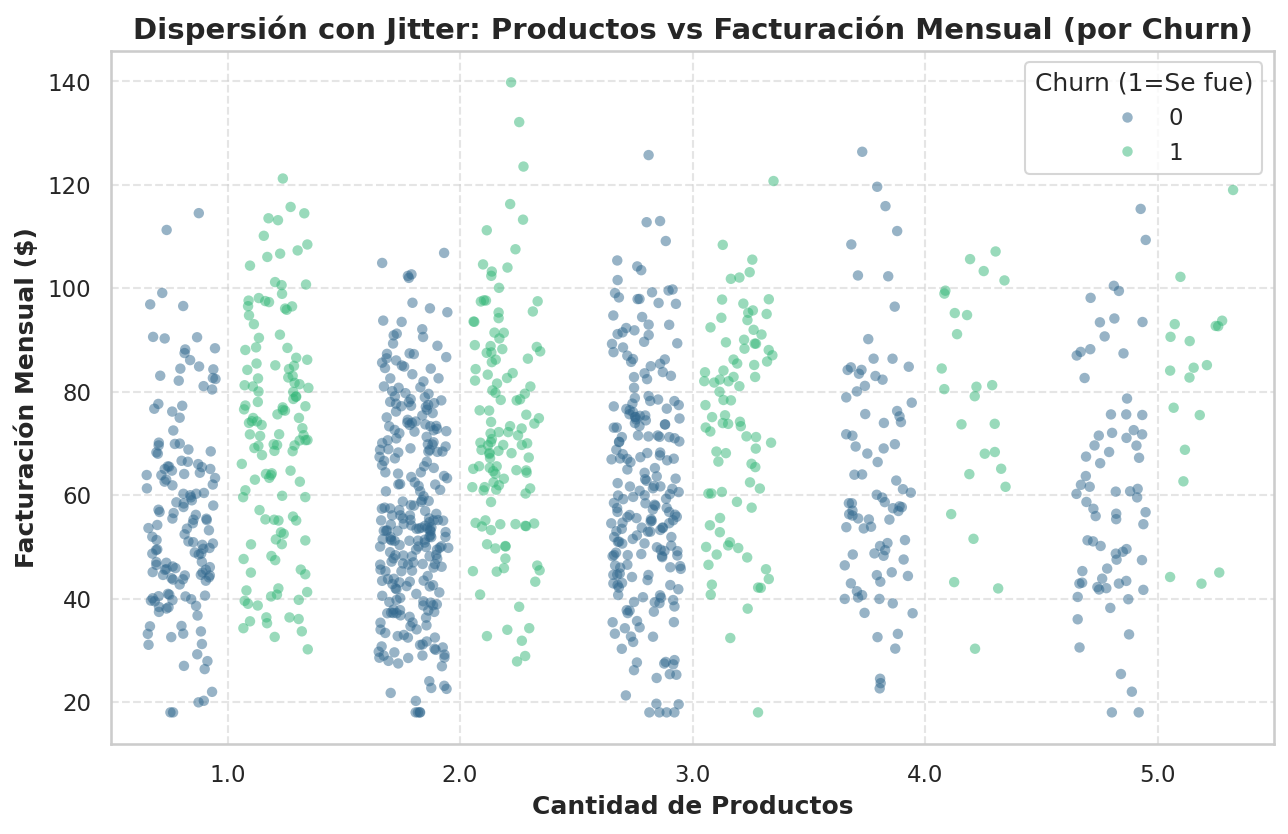

In [272]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=datasetChurnClean, x='productos', y='facturacion_mensual', hue='churn',
              palette='viridis', alpha=0.5, jitter=0.3, dodge=True)
plt.title('Dispersión con Jitter: Productos vs Facturación Mensual (por Churn)')
plt.xlabel('Cantidad de Productos')
plt.ylabel('Facturación Mensual ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Churn (1=Se fue)')
plt.show()

---
##6. Reflexión orientada al preprocesamiento **(Alex - cambiar formato)**

- ¿Qué transformaciones o preprocesamientos serían necesarios antes de alimentar un modelo con estos datos? ¿En qué variables se utilizaría normalización/estandarización? ¿Qué variables deberían pasar por un proceso de codificación (encoding)? ¿Qué método de encoding aplicarían? ¿Hay un orden jerárquico en estas variables que deba preservarse?

Inicialmente deberiamos quitar la *feature* `id_cliente`, ya que solo aporta ruido al analisis.

Luego se deberia resolver que hacer con los espacios nulos y *outliers* de `facturacion_mensual` y `productos`. En el caso de la facturacion mensual, se puede utilizar la mediana para completar los espacios vacios y verificar si los valores atipicos son correctos o errores de tipeo.

In [ ]:
clientes_con_facturacion_alta = datasetChurn[datasetChurn['facturacion_mensual'] > 120]
print(f"Cantidad de clientes con facturación mensual mayor a 120: {len(clientes_con_facturacion_alta)}")

Cantidad de clientes con facturación mensual mayor a 120: 7


Otra solucion seria simplemente eliminar los datos con un valor de facturacion mensual por sobre 120, principalmente porque son pocos datos los que perderiamos.

Para la *feature* productos podriamos simplemente usar la moda para completar los valores nulos.

In [ ]:
clientes_con_5_productos = len(datasetChurn[datasetChurn['productos'] == 5])
print(f"Cantidad de clientes con 5 productos: {clientes_con_5_productos} (un {(clientes_con_5_productos/1200)*100}% de los clientes)")

Cantidad de clientes con 5 productos: 93 (un 7.75% de los clientes)


Y el valor atipico de 5 productos se repite demasiadas veces para ser un error de tipeo, lo mas probable es que existan varios usuarios que necesiten pagar 5 productos simultaneamente.

---
#Ejercicio 3 - Exploración de datos en ausencia de contexto

---
**Dataset:** `dataset_desconocido.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Axel, Bareiro Santiago, Borges Agustin  
**Fecha:** xx/03/2026

>En este ejercicio se introduce un dataset "desconocido", en el que la relación entre las variables y el target es presuntamente no lineal y no resulta evidente a priori.
>
>El dataset contiene múltiples variables numéricas, algunas de las cuales son relevantes para predecir el target y otras son ruído puro. Además, existen valores faltantes y outliers. La variable objetivo (target) es binaria (0 o 1). El dataset se encuentra en el archivo denominado "dataset_desconocido.csv.
>
>El desafío consiste en usar  herramientas visuales y análisis explotario para descrubrir qué variables y qué tipo de relaciones determinan el target. De modo de desarrollar una intuición analítica que permita comprender el comportamiento del sistema, incluso en ausencia de un contexto previo.

---
##0. Configuracion del entorno

In [ ]:
#importación del dataset requerido para el enunciado
datasetDesconocido = pd.read_csv("/content/dataset_desconocido.csv")

---
##1. Carga y primera inspección

In [ ]:
print("Primeras 10 filas del dataset:\n")
datasetDesconocido.head(10)

A simple vista, se puede evidenciar que, a diferencia de enunciados anteriores, no hay un significado claro entre filas o columnas.

In [ ]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetDesconocido.info()

Como observación se puede ver que las primeras 3 variables (x1, x2 y x3) tienen valores nulos ( o faltantes), en cambio, las ultimas 3 variables (x4, x5, y x6) no, por lo cual se puede dividir un claro camino entre grupos de variables a analizar.

In [ ]:
datasetDesconocido.describe()

Haciendo Uso del método `describe()` se observa que la media de cada una de las variables tiende a ser practicamente nula, lo cual es poco útil para el análisis, por otro lado, la desviación estandar provee datos interesantes, denotando una clave separación entre el primer grupo de variables (x1, x2, x3) y el segundo (x4, x5, x6).

En este contexto se podría decir que el modelo no va a aprender de promedios, sino de varianzas

---
##2. Comprensión del target

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Análisis numérico exacto
conteo_target = datasetDesconocido['target'].value_counts()
proporcion_target = datasetDesconocido['target'].value_counts(normalize=True) * 100

print("--- CANTIDAD DE INSTANCIAS POR CLASE DE TARGET ---")
print(conteo_target)
print("\n--- PROPORCIÓN EXACTA (%) DE CLASES DE TARGET ---")
print(proporcion_target.round(2))

# 2. Gráfico para analizar visualmente el balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=datasetDesconocido, x='target', palette=['#1f77b4', '#ff7f0e'])

# Configuramos las etiquetas del gráfico
plt.title('Balance de Clases de la variable Target')
plt.xlabel('Target (0 o 1)')
plt.ylabel('Cantidad de Instancias')

# Agregamos los numeritos arriba de las barras para mayor claridad
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 10))

plt.tight_layout()
plt.show()

Primeramente, se realizó un gráfico de barras de clases de la variable `target` para dataset desconocido, del cual se puede observar lo siguiente

-Para `target 0` existen 554 instancias dando una proporción del 55,4%.

-Para `target 1` existen 446 instancias dando una proporción del 44,6%.

Con esto se evidencia que no hay desbalance significativo, el dataset **se encuentra balanceado**.




### 4.1. Distribución de Variables por Clase de Target (KDE Plots)

In [ ]:
variables_a_graficar = ['x1', 'x2', 'x3']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_a_graficar):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=datasetDesconocido, x=var, hue='target', fill=True, common_norm=False, palette='viridis')
    plt.title(f'KDE de {var} por Target')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

Como podemos observar en los gráficos, las distribuciones de `x1`, `x2` y `x3` muestran diferencias entre las clases del target (0 y 1). Esto sugiere que estas variables tienen algún grado de relevancia para predecir el target, ya que sus patrones de densidad no son idénticos para ambas clases.

In [ ]:
variables_a_graficar_2 = ['x4', 'x5', 'x6']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_a_graficar_2):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=datasetDesconocido, x=var, hue='target', fill=True, common_norm=False, palette='viridis')
    plt.title(f'KDE de {var} por Target')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

Observando los gráficos KDE para `x4`, `x5` y `x6`, notamos que las distribuciones para ambas clases del 'target' (0 y 1) son prácticamente idénticas y se superponen en gran medida. Esto sugiere que, a diferencia de `x1`, `x2` y `x3`, las variables `x4`, `x5` y `x6` tienen una baja o nula capacidad para diferenciar entre las clases del 'target'. En otras palabras, es probable que estas variables no aporten información significativa para la predicción del objetivo y podrían considerarse ruido en el contexto de un modelo predictivo, dando indicios a una probable discriminación de clases marcada.

Otro enfoque se dá al realizar los gráficos Bloxplots de para cada variable en relación a las clases del target:

In [ ]:
variables_a_graficar = ['x1', 'x2', 'x3']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_a_graficar):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=datasetDesconocido, x='target', y=var, palette='viridis')
    plt.title(f'Boxplot de {var} por Target')
    plt.xlabel('Target')
    plt.ylabel(var)

plt.tight_layout()
plt.show()

El análisis de los boxplots para las variables `x1`, `x2` y `x3` en relación con el `target` (0 o 1) revela una clara diferenciación en sus distribuciones. Para `x1`, los valores son consistentemente más bajos en la clase 0 y más altos en la clase 1, indicando una fuerte capacidad discriminatoria. De manera similar, `x2` muestra una separación significativa, con valores más altos para la clase 0 y más bajos para la clase 1. Finalmente, `x3` también presenta distribuciones bien diferenciadas, con valores menores en la clase 0 y mayores en la clase 1.

En conjunto, estos boxplots, al igual que los gráficos KDE previos, sugieren que `x1`, `x2` y `x3` son variables relevantes y prometedoras para la predicción del `target`. Esta capacidad de discriminación contrasta marcadamente con `x4`, `x5` y `x6`, donde las distribuciones entre las clases del `target` se superponían considerablemente, lo que las identifica como variables con menor potencial predictivo.

In [ ]:
variables_ruido = ['x4', 'x5', 'x6']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_ruido):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=datasetDesconocido, x='target', y=var, palette='magma')
    plt.title(f'Boxplot de {var} por Target')
    plt.xlabel('Target')
    plt.ylabel(var)

plt.tight_layout()
plt.show()

Al observar los boxplots de las variables `x4`, `x5` y `x6`, queda en evidencia que las distribuciones son prácticamente idénticas para ambas categorías del target (0 y 1). Las medianas se sitúan en niveles muy similares y los rangos intercuartílicos se solapan casi por completo, lo que indica que estas variables no ofrecen información útil para discriminar entre las clases. A diferencia de lo visto con `x1`, `x2` y `x3`, aquí no se aprecia ningún desplazamiento significativo en los valores que permita establecer una regla de decisión.

Esta uniformidad sugiere que estas variables representan, con alta probabilidad, ruido aleatorio dentro del dataset. Desde el punto de vista del modelado predictivo, incluir variables con este comportamiento suele ser contraproducente, ya que no aportan señal relevante y podrían inducir al modelo a encontrar patrones inexistentes o aumentar innecesariamente la complejidad del sistema sin mejorar la precisión de la clasificación.

---
##3. Correlación y sus limitaciones

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = datasetDesconocido.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación - Dataset Desconocido')
plt.show()

Al observar el mapa de calor, se puede notar que las correlaciones lineales entre las variables (x1 a x6) y el target son extremadamente bajas (cercanas a 0). Esto confirma que la relación entre las variables predictoras y el objetivo probablemente no es lineal, por lo que un análisis de correlación simple de Pearson no logra capturar la dependencia entre ellas. Además, se confirma que no hay colinealidad fuerte entre las variables de entrada.

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=datasetDesconocido, x='x1', y='x2', hue='target', palette='viridis', alpha=0.7)
plt.title('Dispersión de x1 vs x2 por Clase de Target')
plt.xlabel('Variable x1')
plt.ylabel('Variable x2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

La alternativa para encontrar una correlación de dispersiones es realizar un gráfico de dispersión (Scatter Plot) cruzando las variables x1 y x2, diferenciando los colores de los puntos según la clase del target.
Observando los datos de esa manera se nota que los puntos de la clase 1 (target = 1) tienden a agruparse densamente en el centro, cerca del valor (0,0). Por el contrario, los puntos de la clase 0 (target = 0) están esparcidos alrededor de ese centro, formando una especie de nube exterior o anillo grueso.




---
##4. Exploración visual avanzada

In [ ]:
# Generar una matriz de scatter plots para todos los pares de variables
sns.pairplot(datasetDesconocido, hue="target", palette="viridis", diag_kind="kde", plot_kws={'alpha': 0.5})
plt.suptitle("Matriz de Dispersión: Relaciones entre variables por Target", y=1.02)
plt.show()

A partir de la generación del gráfico de una matriz de dispersión (pairplot) para todas las variables del dataset se vuelve mas sencillo observar de forma simultánea como interactúan todos los pares de variables y detectar rápidamente si alguna combinación específica ofrece una separación clara entre las clases 0 y 1.

Se observa una separabilidad visual clara en las combinaciones que involucran a x1, x2 y x3. En particula, los cruces entre estas tres variables muestran nubes de puntos bien definidas para cada clase, lo que sugiere que son las variables con mayor poder predictivo.

Por el contrario, cualquier gráfico que incluya a x4, x5 o x6 muestra una superposición casi total de los puntos (los colores se mezclan completamente), lo que confirma definitivamente que estas tres variables son **ruido** y no aportan información para distinguir entre el target 0 y 1.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aplicamos la transformación cuadrática para linearizar la frontera
dataset_copy = datasetDesconocido.copy()
dataset_copy['x1_sq'] = dataset_copy['x1']**2
dataset_copy['x2_sq'] = dataset_copy['x2']**2

plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset_copy, x='x1_sq', y='x2_sq', hue='target', palette='viridis', alpha=0.7)

# Calculamos un umbral aproximado para la línea divisoria
umbral_r2 = (dataset_copy.groupby('target')['x1_sq'].mean() + dataset_copy.groupby('target')['x2_sq'].mean()).mean()

# Dibujamos la línea de decisión
x_vals = np.linspace(0, 14, 100)
y_vals = umbral_r2 - x_vals
y_vals = np.clip(y_vals, 0, None)

plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label='Frontera de decisión')

# Ajustamos las escalas de los ejes a un máximo de 14
plt.xlim(0, 14)
plt.ylim(0, 14)

plt.title('Transformación: x1² vs x2² (Escala: 0-14)')
plt.xlabel('x1²')
plt.ylabel('x2²')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Se detectó que la relación original entre `x1` y `x2` era de naturaleza circular (no lineal), donde una clase rodeaba a la otra. En estos casos, la transformación más efectiva es **elevar las variables al cuadrado** ($x_1^2, x_2^2$). Esta operación matemática permite mapear los datos a un nuevo espacio de características donde la distancia radial al origen se convierte en una magnitud lineal.

Al graficar esta transformación, se revela una **separación clara y lineal** entre las clases: el grupo central se desplaza hacia el origen, mientras que el anillo exterior se aleja proporcionalmente. Esto permite que un clasificador simple pueda trazar una línea recta (frontera de decisión) para distinguir ambos conjuntos, resolviendo el problema de no linealidad detectado inicialmente en el análisis de dispersión.

---
##5. Outliers y variables irrelavantes

In [ ]:
variables_interes = ['x1', 'x2', 'x3']
plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_interes):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=datasetDesconocido, y=var, x='target', palette='viridis')
    plt.title(f'Outliers en {var} por Target')

plt.tight_layout()
plt.show()

# Cuantificación rápida de outliers (IQR)
for var in ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']:
    q1 = datasetDesconocido[var].quantile(0.25)
    q3 = datasetDesconocido[var].quantile(0.75)
    iqr = q3 - q1
    outliers = ((datasetDesconocido[var] < (q1 - 1.5 * iqr)) | (datasetDesconocido[var] > (q3 + 1.5 * iqr))).sum()
    print(f'Variable {var}: {outliers} outliers detectados.')

### 5. Outliers y Variables Irrelevantes

**Identificación de Outliers:**  
Se observan valores atípicos en las variables `x1`, `x2` y `x3`. Sin embargo, estos no distorsionan la separabilidad visual de manera crítica, ya que la estructura (como el patrón circular entre `x1` y `x2`) permanece claramente definida. Estos outliers podrían representar casos extremos del sistema pero no impiden la identificación de las fronteras de decisión tras las transformaciones adecuadas.

**Identificación de Ruido:**  
Las variables **`x4`, `x5` y `x6`** son identificadas como **ruido puro**. Esto se fundamenta en que sus distribuciones (KDE y Boxplots) son idénticas para ambos targets y su correlación con el objetivo es nula.

**Impacto en el Modelo:**  
Incluir estas variables irrelevantes en el entrenamiento tendría efectos negativos hipotéticos como:
1. **Overfitting (Sobreajuste):** El modelo podría intentar encontrar patrones falsos en el ruido.
2. **Maldición de la Dimensionalidad:** Aumenta la complejidad computacional y la cantidad de datos necesarios para generalizar bien.
3. **Degradación de métricas:** Al diluir la señal de las variables importantes (`x1`, `x2`, `x3`), la precisión del modelo en datos nuevos suele disminuir significativamente.

In [ ]:
# Crear una copia del dataset eliminando las variables identificadas como ruido puro (x4, x5, x6)
# También incluimos las transformaciones x1_sq y x2_sq que resultaron útiles
datasetDesconocido_clean = datasetDesconocido.drop(columns=['x4', 'x5', 'x6']).copy()

print("Dataset limpio creado exitosamente.")
print(f"Columnas restantes: {list(datasetDesconocido_clean.columns)}")
display(datasetDesconocido_clean.head())

Como paso final de la exploración, se procedió a la creación de un nuevo conjunto de datos denominado `datasetDesconocido_clean`. En este proceso, se descartaron las variables **x4, x5 y x6**, ya que el análisis estadístico y visual (KDE, Boxplots y Dispersión) demostró que se comportan como ruido blanco, sin relación alguna con la variable objetivo.

El dataset resultante conserva las variables con alto poder predictivo (x1, x2, x3) junto con las transformaciones cuadráticas que permiten linearizar la frontera de decisión, garantizando así una base de datos más robusta y con mayor relación señal-ruido.

In [ ]:
# Visualización de contraste con el dataset limpio - Escala ampliada
sns.pairplot(datasetDesconocido_clean[['x1', 'x2', 'x3', 'target']],
             hue='target',
             palette='viridis',
             diag_kind='kde',
             height=4,
             aspect=1.2,
             plot_kws={'alpha': 0.5})
plt.suptitle('Contraste de Resultados: Dataset Limpio (Escala Ampliada)', y=1.02)
plt.show()

Al observar detenidamente los gráficos de dispersión donde participa x3 se puede ver que la separación de las clases azules y verdes se da exlusivamente a lo largo del eje x1. En el eje vertical (el de x3), tanto los puntos azules como verdes suben y bajan en las mismas proporciones. La variable x3 no ayuda a encapsular la clase 0; simplemente estira el circulo hacia arriba y abajo, convirtiendolo en una especie de "cilindro" donde la altura (x3) no dice si se encuentra la vista desde adentro o fuera del núcleo.
Dado este "falso positivo" es a todos los efectos prácticos de clasificación, ruido o una pista falsa.

Al considerar x3 como una variable de distracción que no contribuye a la separabilidad geométrica, es descartada, por lo que el dataset se reduce exlusivamente a las variables x1 y x2, entonces, la frontera de decisión final será definida por una circunferencia.

In [ ]:
# Eliminamos la variable x3 del dataset limpio
datasetDesconocido_clean = datasetDesconocido_clean.drop(columns=['x3'])

print("Variable x3 eliminada de datasetDesconocido_clean.")
print(f"Columnas finales: {list(datasetDesconocido_clean.columns)}")
display(datasetDesconocido_clean.head())

In [ ]:
# Calculamos la distancia al cuadrado (r^2)
datasetDesconocido['dist_sq'] = datasetDesconocido['x1']**2 + datasetDesconocido['x2']**2

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico de Dispersión original (x1 vs x2)
sns.scatterplot(data=datasetDesconocido, x='x1', y='x2', hue='target', palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title('Espacio Cartesiano (x1 vs x2)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Histograma de Separabilidad (Cantidad vs Distancia al Cuadrado)
sns.histplot(data=datasetDesconocido, x='dist_sq', hue='target', bins=40, palette='viridis', alpha=0.5, element='step', ax=axes[1])
axes[1].set_title('Separabilidad: Cantidad vs Distancia al Cuadrado (x1² + x2²)')
axes[1].set_xlabel('Distancia al cuadrado (r²)')
axes[1].set_ylabel('Cantidad de Muestras')

plt.tight_layout()
plt.show()

---
##6. Conclusiones Finales **(Falta hacer)**

---
# Resultados y Discusión


---
# Referencias



(Poner resultados generales y conclusión del trabajo práctico acá)

---
# Entorno de Ejecución

In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
